# Notebook 08.2: Real Population Analysis — S-Allele Dataset

Runs the full crossing, equilibrium, and optimisation pipeline on **S-allele genotype data**
(distance-based allele bins from Step 10 of the SRK pipeline).
Data loading and genotype assignment are performed inline — no separate notebook 00 run required.

## Key Differences from Notebook 08.1 (protein-based)

| Feature | 08.1 (proteins) | 08.2 (S-alleles) |
|---|---|---|
| Input matrix | `SRK_individual_genotypes.tsv` (binary, 94 proteins) | `SRK_individual_allele_genotypes.tsv` (counts, 43 allele bins) |
| AABC resolution | Read-depth from `SRK_individual_protein_table.tsv` | Allele counts directly from matrix |
| Extra input files | `SRK_individual_protein_table.tsv`, `SRK_individual_status_report.tsv` | None |
| Genotype patterns | AAAA, AABB, AABC, ABCD | AAAA, AABB, **AAAB**, AABC |
| Allele IDs | `SRK_protein_001` → integer | `Allele_002` → integer |

## Analysis Structure

1. **Within-population analysis** — All major populations (≥5 individuals) analysed independently
2. **Cross-population analysis** — All ingroup individuals treated as a single metapopulation

**PNG output:** Figures saved individually to `outputs/figures/`.


In [1]:
import os
import sys
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.optimize import minimize
from scipy.stats import chisquare

sns.set_style("whitegrid")
np.random.seed(42)
random.seed(42)

# Import all shared utilities
sys.path.insert(0, "../src")
from polyploid_utils import (
    canonical, allele_frequencies, form_gametes, is_compatible,
    cross, crossing_compatibility, sample_offspring, simulate_generation,
    distance_from_equilibrium, enumerate_compatible_crosses,
    compute_greedy_weights, compute_optimal_weights,
    identify_rare_alleles, get_mandatory_rare_crosses, select_elites,
    logistic_n_offspring, effective_population_size, ne_harmonic_mean,
)

# Directories
# Set SALLELES_DIR to the folder containing the S-allele pipeline outputs.
# Default: data/salleles/ — copy pipeline outputs there before running.
DATA_DIR    = os.path.join("..", "data", "salleles")
FIGURES_DIR = os.path.join("..", "outputs", "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

# Color scheme (consistent throughout)
COLOR_RANDOM      = "#8e8e8e"
COLOR_PRESERVED   = "#1565c0"
COLOR_ORIGINAL    = "#c62828"
COLOR_DEMOGRAPHIC = "#2e7d32"

# Simulation parameters
N_YEARS           = 5
N_TRIALS          = 10
SNAPSHOT_YEARS    = [0, 1, 2, 3]
BASE_SEED         = 42
MAJOR_POP_THRESHOLD = 5

print("Imports loaded. Figures will be saved to:", os.path.abspath(FIGURES_DIR))

Imports loaded. Figures will be saved to: /Users/sven/Documents/Current_projects/SRK_bioinformatics/Canu_amplicon/modeling/outputs/figures


## 1. Load and Process Data

Loads three data files from `DATA_DIR`, filters to ingroup individuals,
and assigns deterministic tetraploid genotypes from zygosity patterns:

- **AAAA** (homozygous): 4 copies of a single allele bin
- **AABB** (two-allele, equal): 2 copies each of two allele bins
- **AAAB** (two-allele, dominant): 3 copies of dominant + 1 copy of minor (identified by higher count)
- **AABC** (three-allele): doubled allele identified by highest count in matrix
- **ABCD** (four-allele, if present): 1 copy each of four allele bins


In [2]:
# --- Load data files (encoding='utf-8-sig' handles BOM from Excel-touched TSVs) ---
zygosity_df  = pd.read_csv(os.path.join(DATA_DIR, "SRK_individual_zygosity.tsv"),
                           sep="\t", encoding="utf-8-sig")
genotypes_df = pd.read_csv(os.path.join(DATA_DIR, "SRK_individual_allele_genotypes.tsv"),
                           sep="\t", encoding="utf-8-sig")
metadata_df  = pd.read_csv(os.path.join(DATA_DIR, "sampling_metadata.csv"),
                           encoding="utf-8-sig")

allele_columns = [c for c in genotypes_df.columns if c.startswith("Allele_")]

print("File shapes:")
print(f"  Zygosity:         {zygosity_df.shape[0]} individuals x {zygosity_df.shape[1]} columns")
print(f"  Allele genotypes: {genotypes_df.shape[0]} individuals x {len(allele_columns)} allele bins")
print(f"  Metadata:         {metadata_df.shape[0]} samples")
print(f"\nGenotype pattern distribution:")
print(zygosity_df["Genotype"].value_counts().to_string())

File shapes:
  Zygosity:         189 individuals x 6 columns
  Allele genotypes: 189 individuals x 47 allele bins
  Metadata:         217 samples

Genotype pattern distribution:
Genotype
AAAA    105
AABB     40
AAAB     39
AABC      5


In [3]:
# --- Filter to ingroup individuals only ---
zyg_individuals  = set(zygosity_df["Individual"])
meta_individuals = set(metadata_df["SampleID"])

no_metadata  = zyg_individuals - meta_individuals
outgroup_ids = set(metadata_df[metadata_df["Ingroup"] == 0]["SampleID"])
outgroup_with_data = outgroup_ids & zyg_individuals

# Exclude individuals with unknown/ambiguous genotype pattern
unknown_ids = set(zygosity_df[~zygosity_df["Genotype"].isin(
    ["AAAA", "AABB", "AAAB", "AABC", "ABCD"]
)]["Individual"])

exclude_ids = outgroup_with_data | no_metadata | unknown_ids

print(f"Excluded: {len(outgroup_with_data)} outgroup + {len(no_metadata)} no-metadata + "
      f"{len(unknown_ids)} unknown-pattern = {len(exclude_ids)} total")
if unknown_ids:
    print(f"  Unknown-pattern individuals: {unknown_ids}")

zygosity_filtered  = zygosity_df[~zygosity_df["Individual"].isin(exclude_ids)].copy()
genotypes_filtered = genotypes_df[~genotypes_df["Individual"].isin(exclude_ids)].copy()

print(f"\nIngroup individuals retained: {len(zygosity_filtered)}")
print("Genotype distribution (ingroup):")
print(zygosity_filtered["Genotype"].value_counts().to_string())

Excluded: 0 outgroup + 0 no-metadata + 0 unknown-pattern = 0 total

Ingroup individuals retained: 189
Genotype distribution (ingroup):
Genotype
AAAA    105
AABB     40
AAAB     39
AABC      5


In [4]:
def assign_genotype(individual, genotype_pattern, allele_counts):
    """Assign a tetraploid genotype from zygosity pattern and allele copy counts.

    Parameters
    ----------
    individual : str
        Individual identifier.
    genotype_pattern : str
        One of 'AAAA', 'AABB', 'AAAB', 'AABC', 'ABCD'.
    allele_counts : dict[str, int]
        Copy counts per allele bin (only non-zero alleles from count matrix).

    Returns
    -------
    tuple[str, ...]
        Sorted 4-element tuple of allele bin names.
    str
        Assignment method description.
    """
    alleles = sorted(allele_counts.keys())
    n = len(alleles)

    if genotype_pattern == "AAAA":
        if n != 1:
            raise ValueError(f"{individual}: AAAA but {n} alleles detected")
        a = alleles[0]
        return tuple([a] * 4), "homozygous_4x"

    elif genotype_pattern == "AABB":
        if n != 2:
            raise ValueError(f"{individual}: AABB but {n} alleles detected")
        a, b = alleles[0], alleles[1]
        return tuple(sorted([a, a, b, b])), "heterozygous_2x2"

    elif genotype_pattern == "AAAB":
        if n != 2:
            raise ValueError(f"{individual}: AAAB but {n} alleles detected")
        # Allele with higher count is the dominant (tripled) allele
        dominant = max(alleles, key=lambda x: (allele_counts[x], x))
        minor = [x for x in alleles if x != dominant][0]
        return tuple(sorted([dominant, dominant, dominant, minor])), "heterozygous_3x1"

    elif genotype_pattern == "AABC":
        if n != 3:
            raise ValueError(f"{individual}: AABC but {n} alleles detected")
        doubled = max(alleles, key=lambda x: (allele_counts[x], x))
        singles = sorted([x for x in alleles if x != doubled])
        return tuple(sorted([doubled, doubled] + singles)), "heterozygous_2x1x1"

    elif genotype_pattern == "ABCD":
        if n != 4:
            raise ValueError(f"{individual}: ABCD but {n} alleles detected")
        return tuple(sorted(alleles)), "heterozygous_1x4"

    else:
        raise ValueError(f"{individual}: unknown genotype pattern '{genotype_pattern}'")


# --- Apply assignment to all ingroup individuals ---
geno_indexed = genotypes_filtered.set_index("Individual")[allele_columns]
zyg_indexed  = zygosity_filtered.set_index("Individual")

records = []
for ind in zygosity_filtered["Individual"]:
    pattern   = zyg_indexed.loc[ind, "Genotype"]
    row_counts = geno_indexed.loc[ind]
    ac = {col: int(row_counts[col]) for col in allele_columns if row_counts[col] > 0}
    genotype, method = assign_genotype(ind, pattern, ac)
    records.append({
        "individual":       ind,
        "genotype_pattern": pattern,
        "detected_alleles": list(ac.keys()),
        "allele_counts":    ac,
        "genotype":         genotype,
        "method":           method,
    })

assignments_df = pd.DataFrame(records)
print(f"Assigned genotypes for {len(assignments_df)} individuals.")

Assigned genotypes for 189 individuals.


In [5]:
# --- Map allele bin names to integer IDs ---
sorted_allele_names = sorted(allele_columns)
name_to_id = {name: i + 1 for i, name in enumerate(sorted_allele_names)}
id_to_name = {v: k for k, v in name_to_id.items()}
allele_pool_full = sorted(name_to_id.values())

# Convert genotypes to integer IDs
population_genotypes = []
individual_names     = []
for _, row in assignments_df.iterrows():
    int_genotype = tuple(sorted(name_to_id[a] for a in row["genotype"]))
    population_genotypes.append(int_genotype)
    individual_names.append(row["individual"])

# --- Population grouping ---
meta_lookup = metadata_df.set_index("SampleID")[["Pop", "EO_w_sub"]]
pop_map = {}
for ind in individual_names:
    pop_map[ind] = str(meta_lookup.loc[ind, "Pop"]) if ind in meta_lookup.index else "unknown"

assignments_df["pop"] = assignments_df["individual"].map(pop_map)

pop_populations = {}  # Pop -> list of int genotype tuples
pop_individuals = {}  # Pop -> list of individual names
for i, (_, row) in enumerate(assignments_df.iterrows()):
    p = row["pop"]
    pop_populations.setdefault(p, []).append(population_genotypes[i])
    pop_individuals.setdefault(p, []).append(row["individual"])

print(f"Total individuals: {len(individual_names)}")
print(f"Total allele bins (integer IDs): {len(allele_pool_full)}")
print(f"Total populations: {len(pop_populations)}")

Total individuals: 189
Total allele bins (integer IDs): 47
Total populations: 26


## 2. Population Overview

In [6]:
pop_counts = pd.Series({p: len(v) for p, v in pop_populations.items()}).sort_values(ascending=False)
major_pops = sorted([p for p, inds in pop_populations.items() if len(inds) >= MAJOR_POP_THRESHOLD])
minor_pops = sorted([p for p, inds in pop_populations.items() if len(inds) < MAJOR_POP_THRESHOLD])

print(f"=== Major Populations (≥{MAJOR_POP_THRESHOLD} individuals) ===")
print(f"{'Pop':<8} {'N':>5} {'Alleles':>8} {'Unique geno':>12} {'Chi-sq':>10} {'Variance':>10}")
print("-" * 56)
for pop in major_pops:
    genotypes = pop_populations[pop]
    alleles   = sorted(set(a for g in genotypes for a in g))
    d = distance_from_equilibrium(genotypes, alleles)
    print(f"{pop:<8} {len(genotypes):>5} {len(alleles):>8} {len(set(genotypes)):>12} "
          f"{d['chi_squared']:>10.4f} {d['variance']:>10.6f}")

print(f"\nMinor populations: {minor_pops}")
print(f"\nSpecies-wide total: {len(population_genotypes)} individuals, "
      f"{len(set(a for g in population_genotypes for a in g))} allele bins")

=== Major Populations (≥5 individuals) ===
Pop          N  Alleles  Unique geno     Chi-sq   Variance
--------------------------------------------------------
25          32       11           17     1.5311   0.012654
27          29       15           18     1.3588   0.006039
67          32       12           21     1.3057   0.009067
70          40        6           12     1.0831   0.030087
76          25        9           15     0.5768   0.007121

Minor populations: ['118', '15', '18', '24', '26-3', '29', '38', '405', '48', '52', '61', '68', '702-24', '702-3', '704', '709', '712-5', '715-1', '8', '84-2', '96-16']

Species-wide total: 189 individuals, 47 allele bins


## Part A: Within-Population Analysis

For each major population (≥5 individuals):
1. Enumerate all SI-compatible crosses
2. Optimise crossing weights via L-BFGS-B (minimise χ² from uniform allele frequencies)
3. Run 10-trial adaptive simulations for 5 years under 4 strategies

In [7]:
%%time

group_data = {}

for pop in major_pops:
    genotypes = pop_populations[pop]
    names     = pop_individuals[pop]
    alleles   = sorted(set(a for g in genotypes for a in g))
    target    = 1.0 / len(alleles)

    cc, aem = enumerate_compatible_crosses(genotypes, alleles)
    n_total = len(genotypes) * (len(genotypes) - 1)

    group_data[pop] = {
        "pop":                genotypes,
        "individuals":        names,
        "allele_pool":        alleles,
        "target_freq":        target,
        "compatible_crosses": cc,
        "allele_effect_matrix": aem,
    }
    print(f"Pop {pop}: {len(genotypes)} ind, {len(alleles)} allele bins, "
          f"{len(cc)}/{n_total} compatible crosses ({100*len(cc)/n_total:.1f}%)")

Pop 25: 32 ind, 11 allele bins, 749/992 compatible crosses (75.5%)
Pop 27: 29 ind, 15 allele bins, 692/812 compatible crosses (85.2%)
Pop 67: 32 ind, 12 allele bins, 802/992 compatible crosses (80.8%)
Pop 70: 40 ind, 6 allele bins, 927/1560 compatible crosses (59.4%)
Pop 76: 25 ind, 9 allele bins, 488/600 compatible crosses (81.3%)
CPU times: user 56.8 ms, sys: 523 µs, total: 57.4 ms
Wall time: 57.4 ms


In [8]:
%%time

for pop in major_pops:
    gd         = group_data[pop]
    cc         = gd["compatible_crosses"]
    aem        = gd["allele_effect_matrix"]
    alleles    = gd["allele_pool"]
    n_crosses  = len(cc)
    target     = gd["target_freq"]

    w0           = np.ones(n_crosses) / n_crosses
    expected     = w0 @ aem
    baseline_chi = float(np.sum((expected - target) ** 2 / target))

    optimal_weights, result = compute_optimal_weights(cc, aem, alleles, maxiter=5000)
    gd["optimal_weights"] = optimal_weights
    gd["opt_result"]      = result
    gd["baseline_chi"]    = baseline_chi

    print(f"Pop {pop}: baseline χ²={baseline_chi:.4f}, "
          f"optimised χ²={result.fun:.6f}, converged={result.success}")

Pop 25: baseline χ²=0.8697, optimised χ²=0.000000, converged=True
Pop 27: baseline χ²=1.0163, optimised χ²=0.029056, converged=True
Pop 67: baseline χ²=0.8271, optimised χ²=0.036468, converged=True
Pop 70: baseline χ²=0.8236, optimised χ²=0.071429, converged=True
Pop 76: baseline χ²=0.4411, optimised χ²=0.046512, converged=True
CPU times: user 242 ms, sys: 636 ms, total: 877 ms
Wall time: 97.4 ms


### Within-Population Simulation (5 Years)

Four strategies, 10 stochastic trials each.

- **Random** (gray): uniform random pairing among SI-compatible pairs
- **Optimised** (red): L-BFGS-B weights, no rare-allele protection
- **Optimised + preservation** (blue): adds elitism, mandatory rare-allele crosses, and optimiser penalty
- **Optimised + preservation + demography** (green): adds logistic population growth with Poisson noise

In [9]:
def run_adaptive_simulation(pop, allele_pool, n_gen, strategy, n_trials=10,
                            opt_maxiter=200, preserve_rare=False,
                            rare_threshold=0.05, elite_frac=0.1,
                            carrying_capacity=None, growth_rate=0.5,
                            demographic_stochastic=True, base_seed=42,
                            verbose=False):
    """Run multi-trial adaptive simulation with optional preservation and demography.

    Parameters
    ----------
    pop : list[tuple]
        Starting population genotypes.
    allele_pool : list[int]
        All allele IDs to track.
    n_gen : int
        Number of generations to simulate.
    strategy : str
        'random' or 'optimized'.
    n_trials : int
        Number of independent stochastic trials.
    opt_maxiter : int
        L-BFGS-B max iterations per generation.
    preserve_rare : bool
        If True, apply elitism + mandatory rare-allele crosses + optimizer penalty.
    rare_threshold : float
        Allele frequency below which allele is considered rare.
    elite_frac : float
        Fraction of top-rarity individuals carried forward unchanged.
    carrying_capacity : int or None
        If set, population size follows logistic growth toward this K.
    growth_rate : float
        Intrinsic growth rate r for logistic growth.
    demographic_stochastic : bool
        Add Poisson noise to offspring count.
    base_seed : int
        Trial t uses seed base_seed + t (shared across strategies for fair comparison).

    Returns
    -------
    dict
        Mean and std arrays for variance, chi-squared, extinct alleles,
        endangered alleles, population size, Ne, and snapshots.
    """
    all_variances   = np.zeros((n_trials, n_gen + 1))
    all_chi_sq      = np.zeros((n_trials, n_gen + 1))
    all_extinct     = np.zeros((n_trials, n_gen + 1))
    all_endangered  = np.zeros((n_trials, n_gen + 1))
    all_pop_sizes   = np.zeros((n_trials, n_gen + 1))
    all_ne          = np.zeros((n_trials, n_gen + 1))
    snapshots = {}

    for trial in range(n_trials):
        if verbose:
            print(f"    trial {trial+1}/{n_trials}...", end=" ", flush=True)
        np.random.seed(base_seed + trial)
        random.seed(base_seed + trial)
        current_pop = list(pop)

        for gen in range(n_gen + 1):
            d = distance_from_equilibrium(current_pop, allele_pool)
            all_variances[trial, gen]  = d["variance"]
            all_chi_sq[trial, gen]     = d["chi_squared"]
            all_extinct[trial, gen]    = d["extinct_alleles"]
            all_endangered[trial, gen] = d["endangered_alleles"]
            all_pop_sizes[trial, gen]  = len(current_pop)

            if len(current_pop) <= 60:
                ne_info = effective_population_size(current_pop, allele_pool)
                all_ne[trial, gen] = ne_info["Ne"]
            else:
                all_ne[trial, gen] = np.nan

            if trial == n_trials - 1:
                snapshots[gen] = list(current_pop)

            if gen < n_gen:
                if carrying_capacity is not None:
                    n_off = logistic_n_offspring(
                        len(current_pop), carrying_capacity,
                        r=growth_rate, stochastic=demographic_stochastic)
                else:
                    n_off = len(pop)  # fixed at original size

                if strategy == "random":
                    current_pop = simulate_generation(
                        current_pop, n_offspring=n_off,
                        allele_pool=allele_pool if preserve_rare else None,
                        preserve_rare=preserve_rare,
                        rare_threshold=rare_threshold,
                        elite_frac=elite_frac,
                    )
                else:
                    cc, aem = enumerate_compatible_crosses(current_pop, allele_pool)
                    rare_idx = None
                    if preserve_rare:
                        freqs = allele_frequencies(current_pop, allele_pool)
                        sorted_alleles = sorted(allele_pool)
                        rare_idx = [i for i, a in enumerate(sorted_alleles)
                                    if 0 < freqs.get(a, 0) < rare_threshold]
                    weights, _ = compute_optimal_weights(
                        cc, aem, allele_pool, maxiter=opt_maxiter,
                        rare_allele_indices=rare_idx,
                    )
                    plan = [(cc[k][0], cc[k][1], weights[k])
                            for k in range(len(cc)) if weights[k] > 1e-6]
                    current_pop = simulate_generation(
                        current_pop, n_offspring=n_off, crossing_plan=plan,
                        allele_pool=allele_pool if preserve_rare else None,
                        preserve_rare=preserve_rare,
                        rare_threshold=rare_threshold,
                        elite_frac=elite_frac,
                    )

        if verbose:
            print("done")
    return {
        "variance_mean":    all_variances.mean(axis=0),
        "variance_std":     all_variances.std(axis=0),
        "chi_sq_mean":      all_chi_sq.mean(axis=0),
        "chi_sq_std":       all_chi_sq.std(axis=0),
        "extinct_mean":     all_extinct.mean(axis=0),
        "extinct_std":      all_extinct.std(axis=0),
        "endangered_mean":  all_endangered.mean(axis=0),
        "endangered_std":   all_endangered.std(axis=0),
        "pop_size_mean":    all_pop_sizes.mean(axis=0),
        "pop_size_std":     all_pop_sizes.std(axis=0),
        "ne_mean":          np.where(np.all(np.isnan(all_ne), axis=0), np.nan, np.nanmean(all_ne, axis=0)),
        "ne_std":           np.where(np.all(np.isnan(all_ne), axis=0), np.nan, np.nanstd(all_ne, axis=0)),
        "snapshots":        snapshots,
    }

In [10]:
%%time

for pop_id in major_pops:
    gd = group_data[pop_id]
    pop = gd["pop"]
    alleles = gd["allele_pool"]
    N0 = len(pop)
    K = max(N0 * 3, 30)
    print(f"\nPop {pop_id} ({N0} ind, {len(alleles)} allele bins, K={K}):")

    print("  Random mating...")
    gd["random"] = run_adaptive_simulation(
        pop, alleles, N_YEARS, "random", N_TRIALS, base_seed=BASE_SEED)

    print("  Optimized (no preservation)...")
    gd["optimized"] = run_adaptive_simulation(
        pop, alleles, N_YEARS, "optimized", N_TRIALS, base_seed=BASE_SEED)

    print("  Optimized + preservation...")
    gd["preserved"] = run_adaptive_simulation(
        pop, alleles, N_YEARS, "optimized", N_TRIALS,
        opt_maxiter=50, preserve_rare=True, rare_threshold=0.05, elite_frac=0.1,
        base_seed=BASE_SEED, verbose=True)

    print("  Optimized + preservation + demography...")
    gd["demographic"] = run_adaptive_simulation(
        pop, alleles, N_YEARS, "optimized", N_TRIALS,
        opt_maxiter=50, preserve_rare=True, rare_threshold=0.05, elite_frac=0.1,
        carrying_capacity=K, growth_rate=0.5, demographic_stochastic=True,
        base_seed=BASE_SEED, verbose=True)

    r = gd["random"]; o = gd["optimized"]; p = gd["preserved"]; dm = gd["demographic"]
    for yr in SNAPSHOT_YEARS:
        if yr <= N_YEARS:
            imp_o = (1 - o["variance_mean"][yr] / max(r["variance_mean"][yr], 1e-12)) * 100
            imp_p = (1 - p["variance_mean"][yr] / max(r["variance_mean"][yr], 1e-12)) * 100
            imp_d = (1 - dm["variance_mean"][yr] / max(r["variance_mean"][yr], 1e-12)) * 100
            print(f"  Year {yr}: Random var={r['variance_mean'][yr]:.6f}, "
                  f"Opt={o['variance_mean'][yr]:.6f} ({imp_o:.0f}%), "
                  f"Pres={p['variance_mean'][yr]:.6f} ({imp_p:.0f}%), "
                  f"Demo={dm['variance_mean'][yr]:.6f} ({imp_d:.0f}%)")
            print(f"           Extinct: R={r['extinct_mean'][yr]:.1f}, "
                  f"O={o['extinct_mean'][yr]:.1f}, P={p['extinct_mean'][yr]:.1f}, "
                  f"D={dm['extinct_mean'][yr]:.1f} | "
                  f"Pop size (demo): {dm['pop_size_mean'][yr]:.0f}")

print("\nDone.")


Pop 25 (32 ind, 11 allele bins, K=96):
  Random mating...
  Optimized (no preservation)...
  Optimized + preservation...
    trial 1/10... done
    trial 2/10... done
    trial 3/10... done
    trial 4/10... done
    trial 5/10... done
    trial 6/10... done
    trial 7/10... done
    trial 8/10... done
    trial 9/10... done
    trial 10/10... done
  Optimized + preservation + demography...
    trial 1/10... done
    trial 2/10... done
    trial 3/10... done
    trial 4/10... done
    trial 5/10... done
    trial 6/10... done
    trial 7/10... done
    trial 8/10... done
    trial 9/10... done
    trial 10/10... done
  Year 0: Random var=0.012654, Opt=0.012654 (0%), Pres=0.012654 (0%), Demo=0.012654 (0%)
           Extinct: R=0.0, O=0.0, P=0.0, D=0.0 | Pop size (demo): 32
  Year 1: Random var=0.007702, Opt=0.000784 (90%), Pres=0.000943 (88%), Demo=0.000671 (91%)
           Extinct: R=0.2, O=0.0, P=0.0, D=0.0 | Pop size (demo): 42
  Year 2: Random var=0.005053, Opt=0.000501 (90%), Pre

/var/folders/7q/9sxlsr1j6xg80n7_3mmyx_nr0000gp/T/ipykernel_15873/2326443061.py:127: RuntimeWarning: Mean of empty slice
  "ne_mean":          np.where(np.all(np.isnan(all_ne), axis=0), np.nan, np.nanmean(all_ne, axis=0)),
/Users/sven/anaconda3/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


  Optimized (no preservation)...
  Optimized + preservation...
    trial 1/10... done
    trial 2/10... done
    trial 3/10... done
    trial 4/10... done
    trial 5/10... done
    trial 6/10... done
    trial 7/10... done
    trial 8/10... done
    trial 9/10... done
    trial 10/10... done
  Optimized + preservation + demography...
    trial 1/10... done
    trial 2/10... done
    trial 3/10... done
    trial 4/10... done
    trial 5/10... done
    trial 6/10... done
    trial 7/10... done
    trial 8/10... done
    trial 9/10... done
    trial 10/10... done
  Year 0: Random var=0.009067, Opt=0.009067 (0%), Pres=0.009067 (0%), Demo=0.009067 (0%)
           Extinct: R=0.0, O=0.0, P=0.0, D=0.0 | Pop size (demo): 32
  Year 1: Random var=0.006718, Opt=0.001218 (82%), Pres=0.001544 (77%), Demo=0.001317 (80%)
           Extinct: R=1.3, O=0.0, P=0.0, D=0.0 | Pop size (demo): 42
  Year 2: Random var=0.004518, Opt=0.000638 (86%), Pres=0.000707 (84%), Demo=0.000519 (89%)
           Extinct: R

### Allele Frequency Distributions by Strategy

**Chart Set 1** — Random (gray) vs. Optimised + Preservation (blue).

**Chart Set 2** — Original Optimisation (red) vs. Optimised + Preservation (blue).

Figures are saved as individual PNGs per population.

  Saved: ../outputs/figures/sallele_pop25_allele_freq_random.png


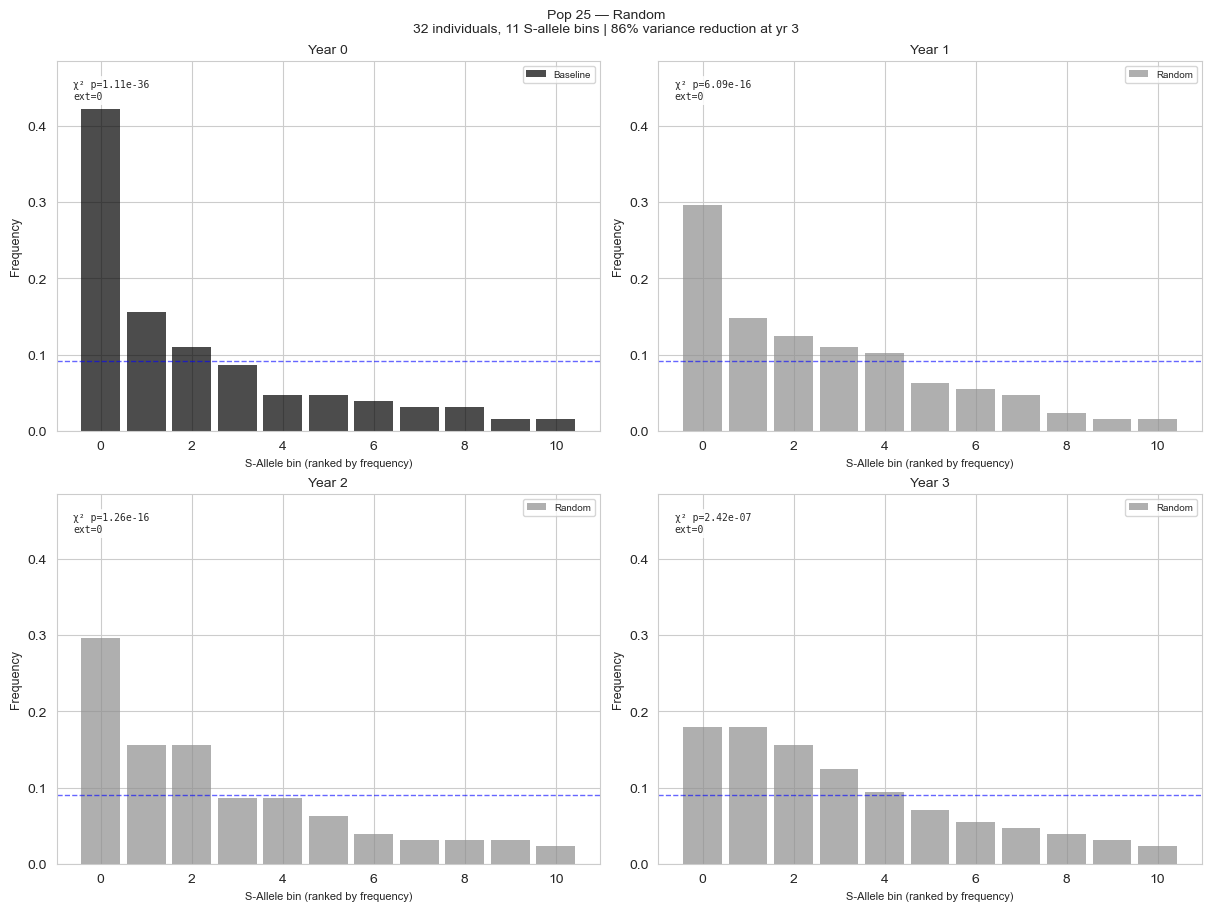

  Saved: ../outputs/figures/sallele_pop25_allele_freq_preserved.png


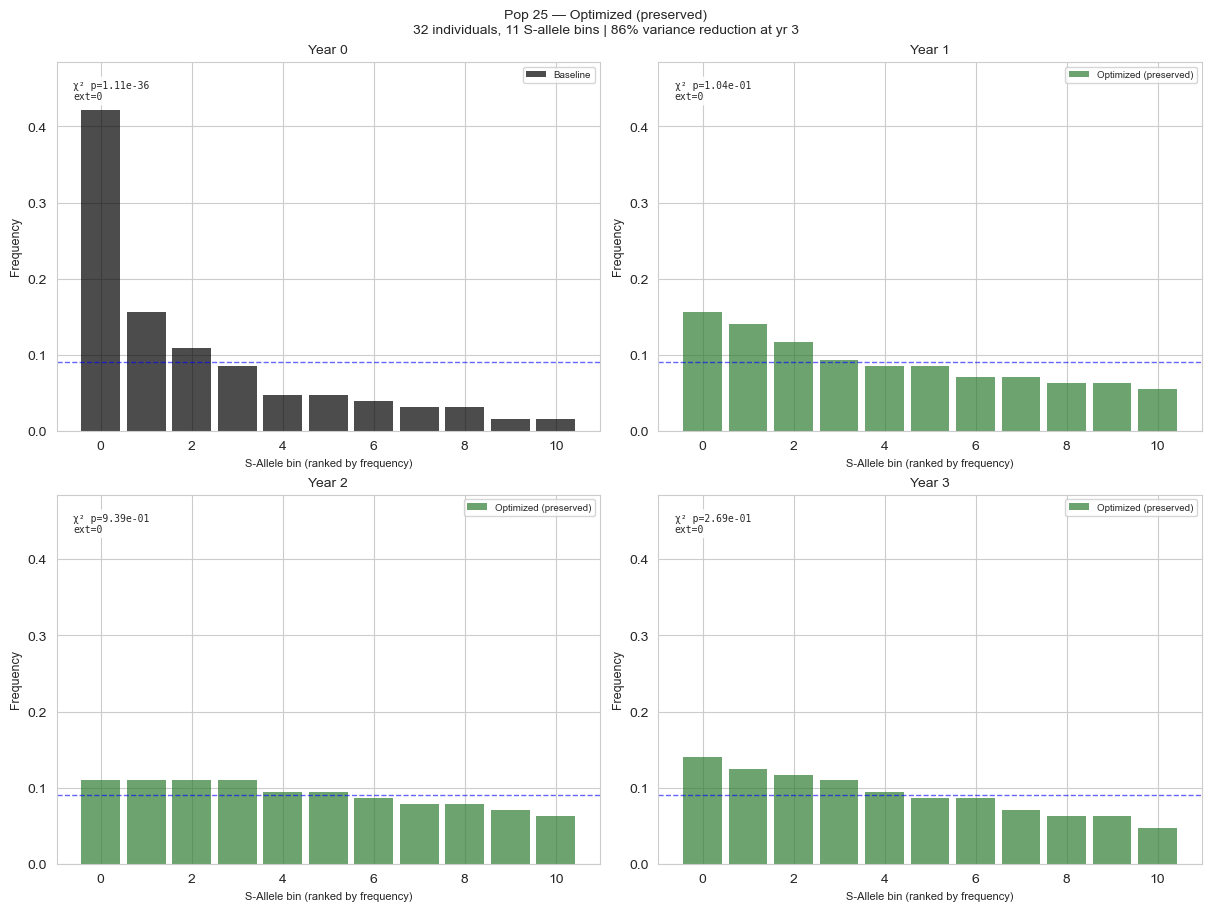

  Saved: ../outputs/figures/sallele_pop27_allele_freq_random.png


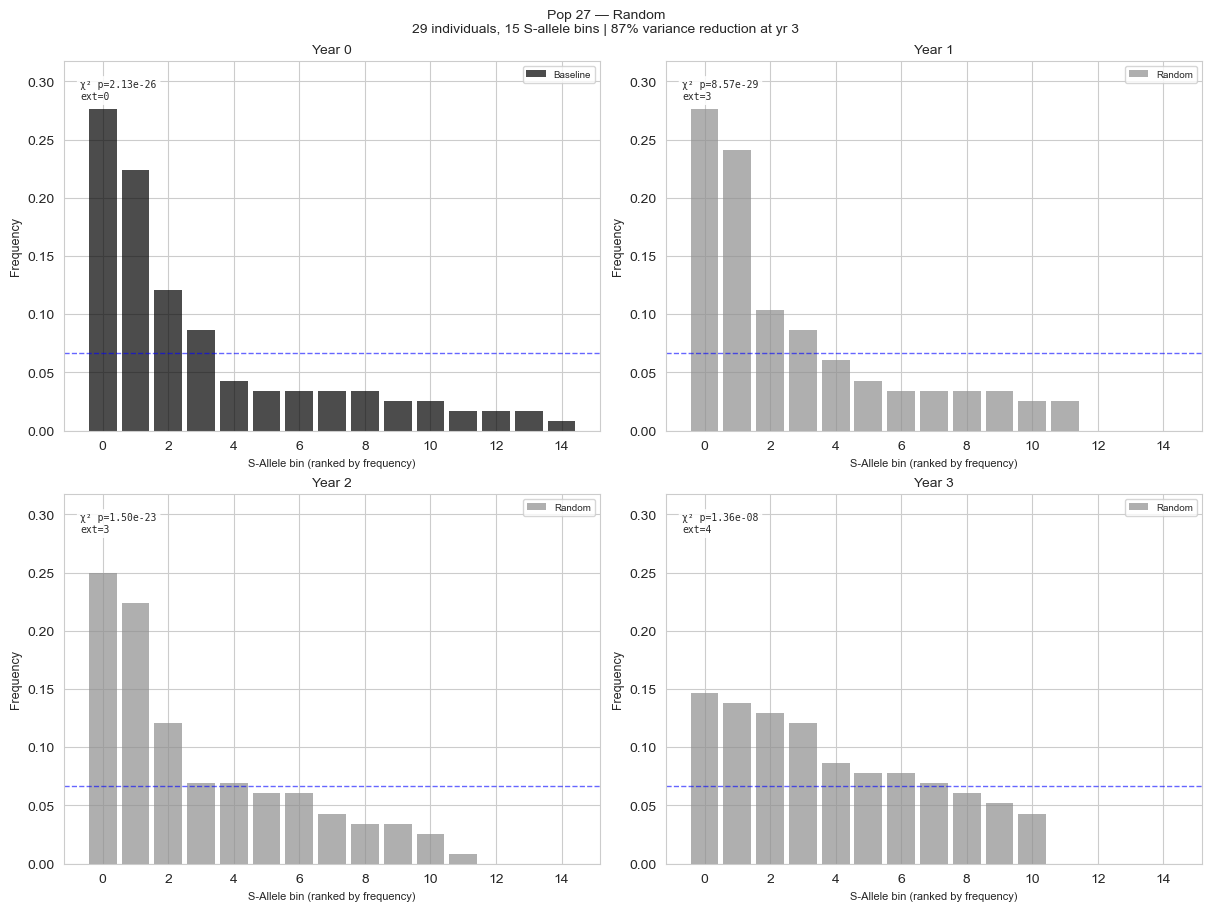

  Saved: ../outputs/figures/sallele_pop27_allele_freq_preserved.png


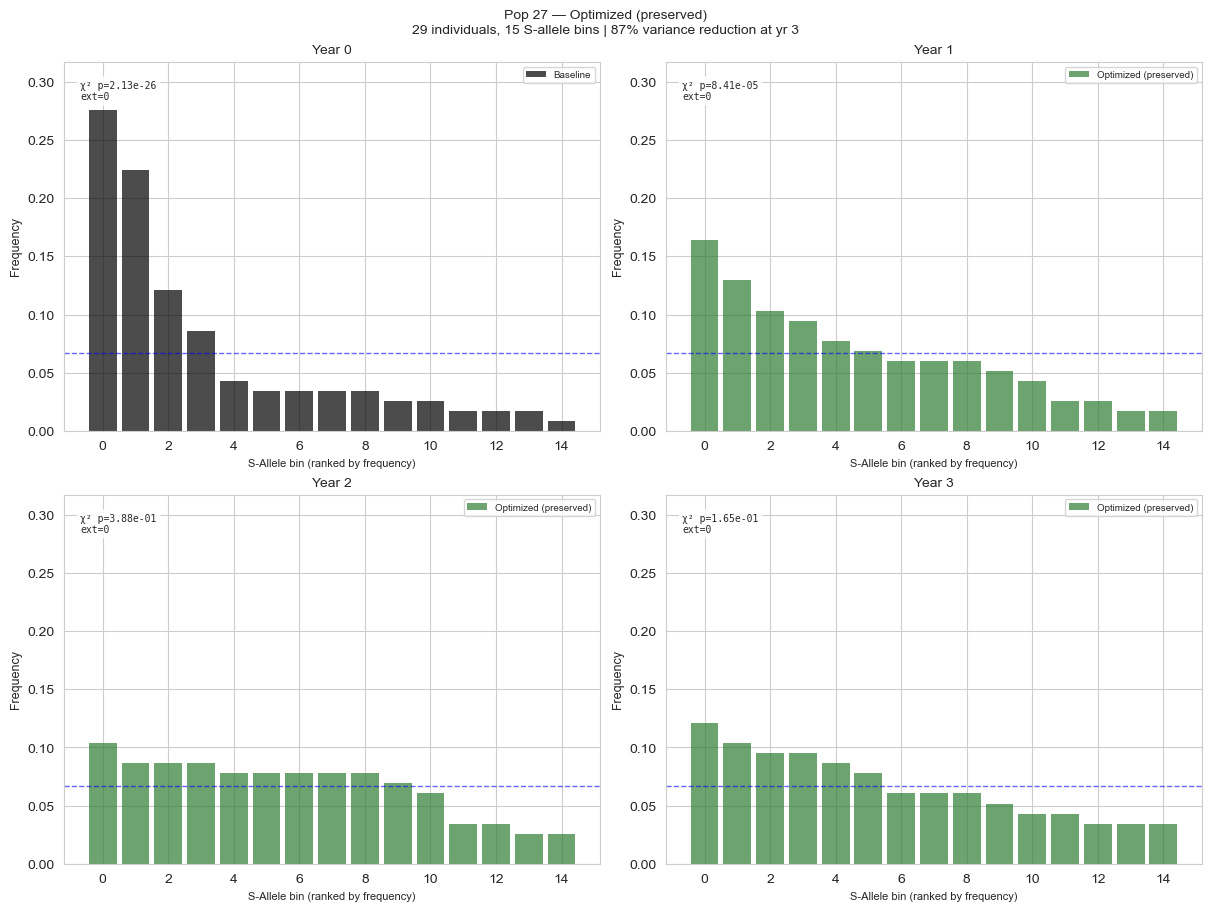

  Saved: ../outputs/figures/sallele_pop67_allele_freq_random.png


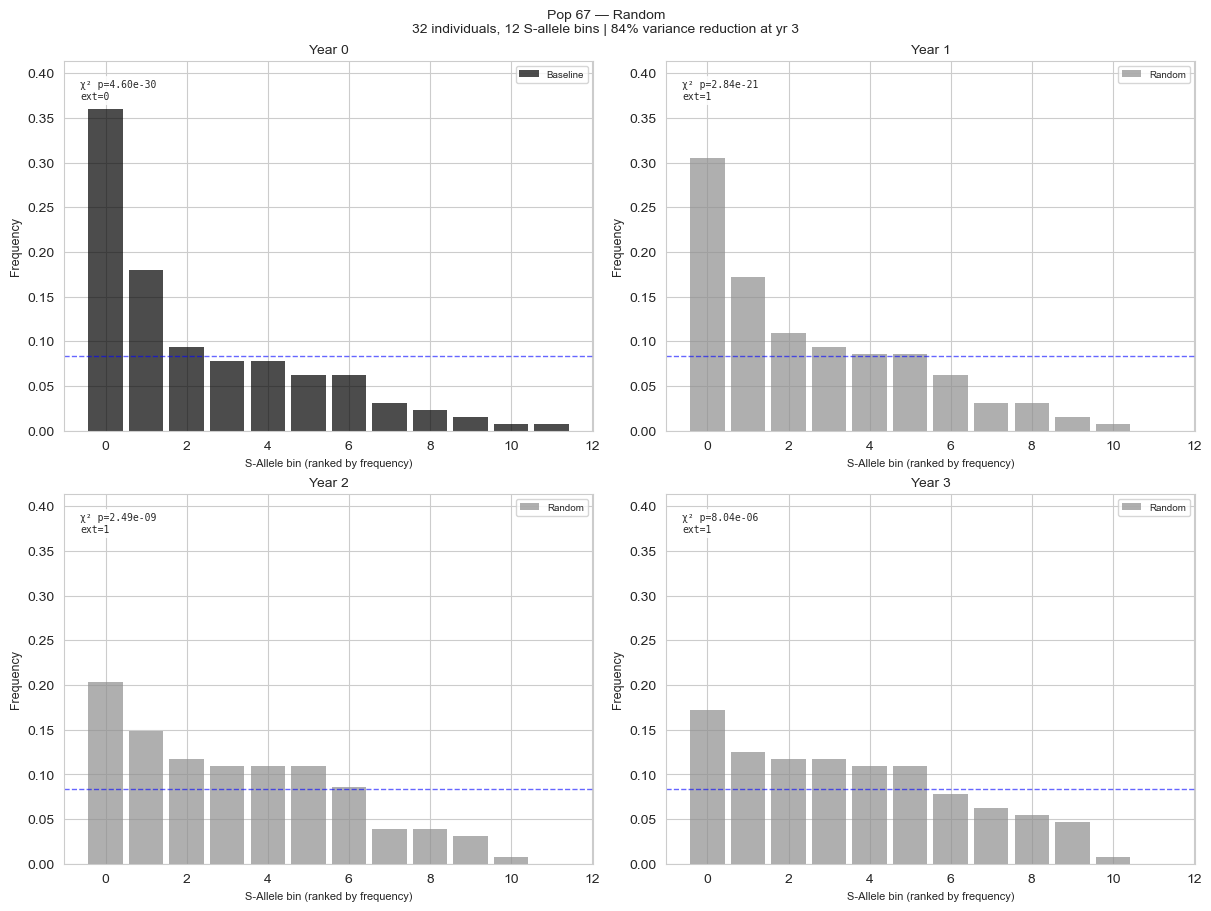

  Saved: ../outputs/figures/sallele_pop67_allele_freq_preserved.png


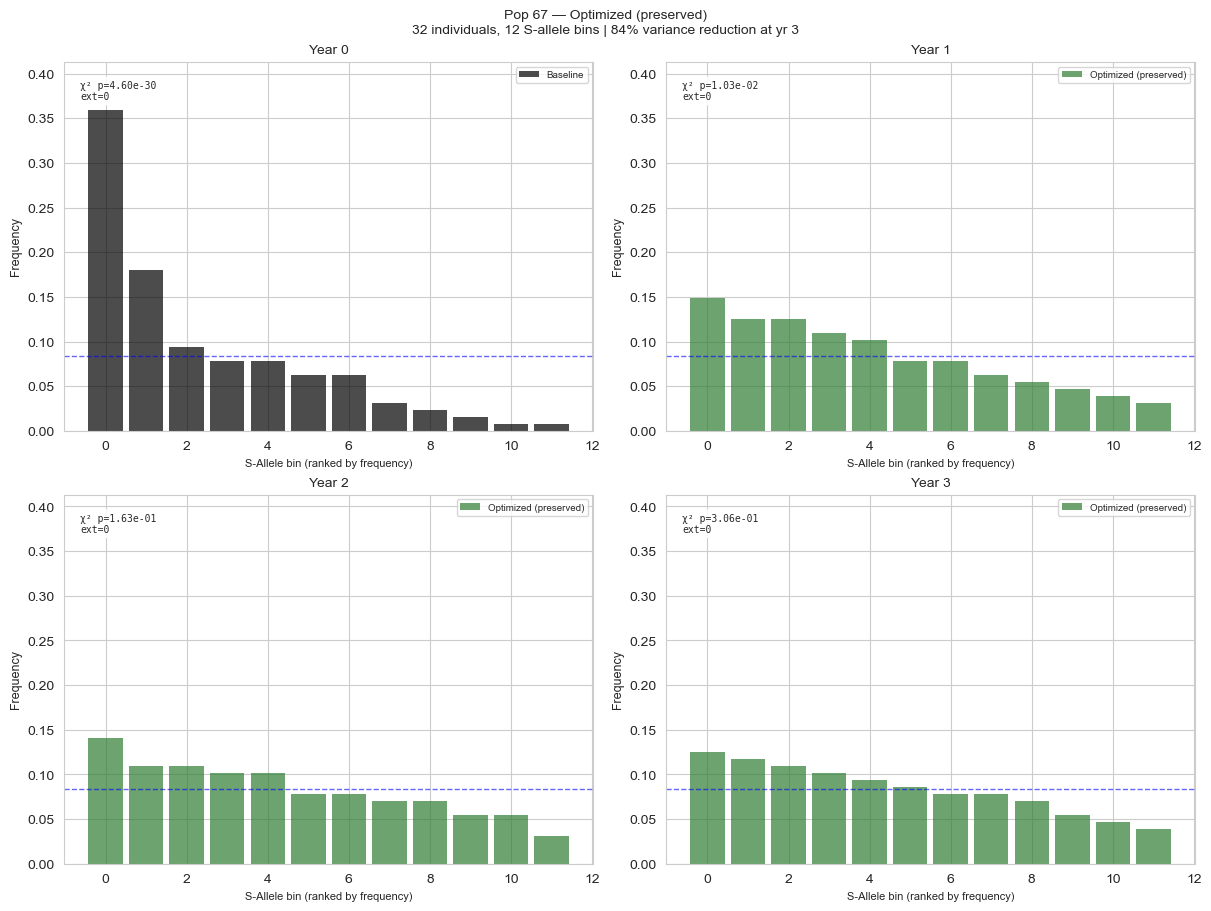

  Saved: ../outputs/figures/sallele_pop70_allele_freq_random.png


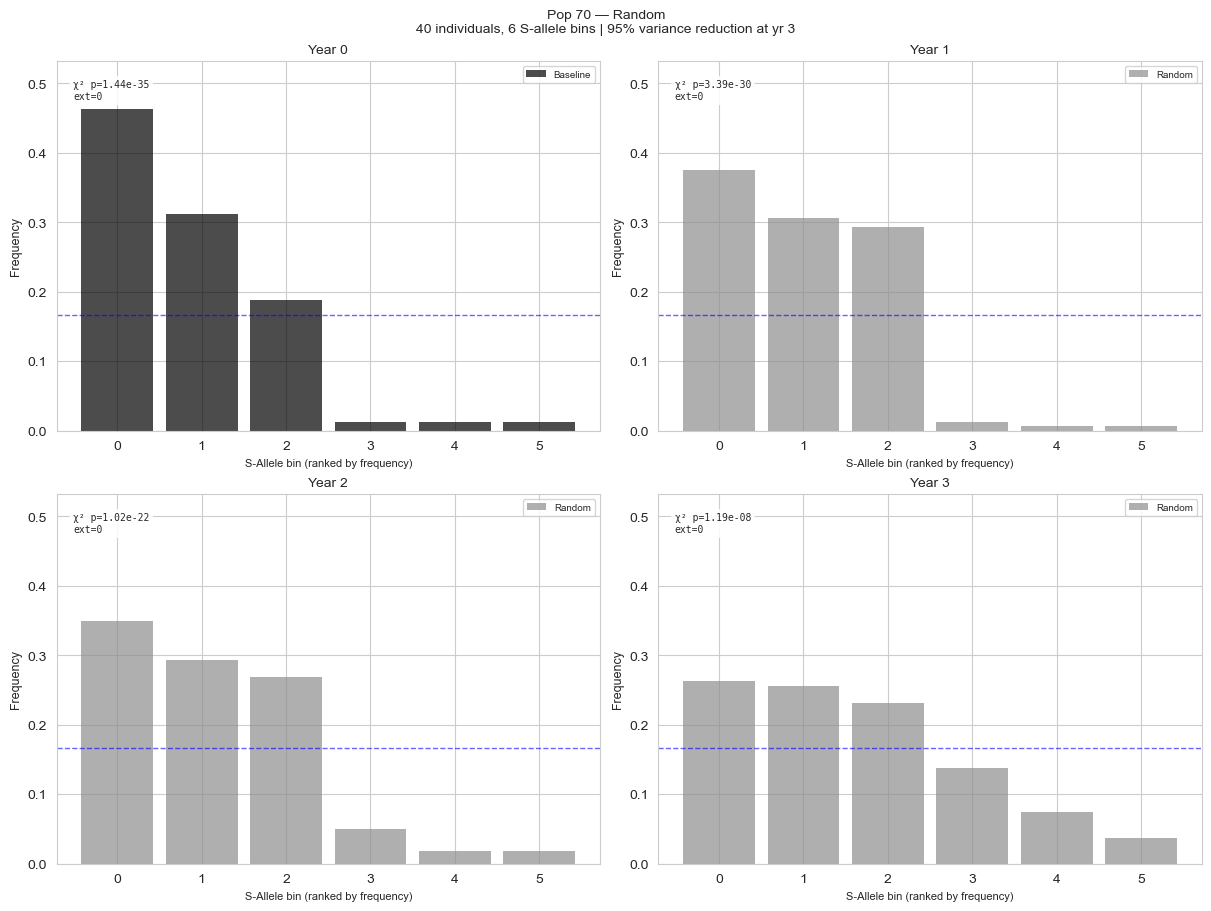

  Saved: ../outputs/figures/sallele_pop70_allele_freq_preserved.png


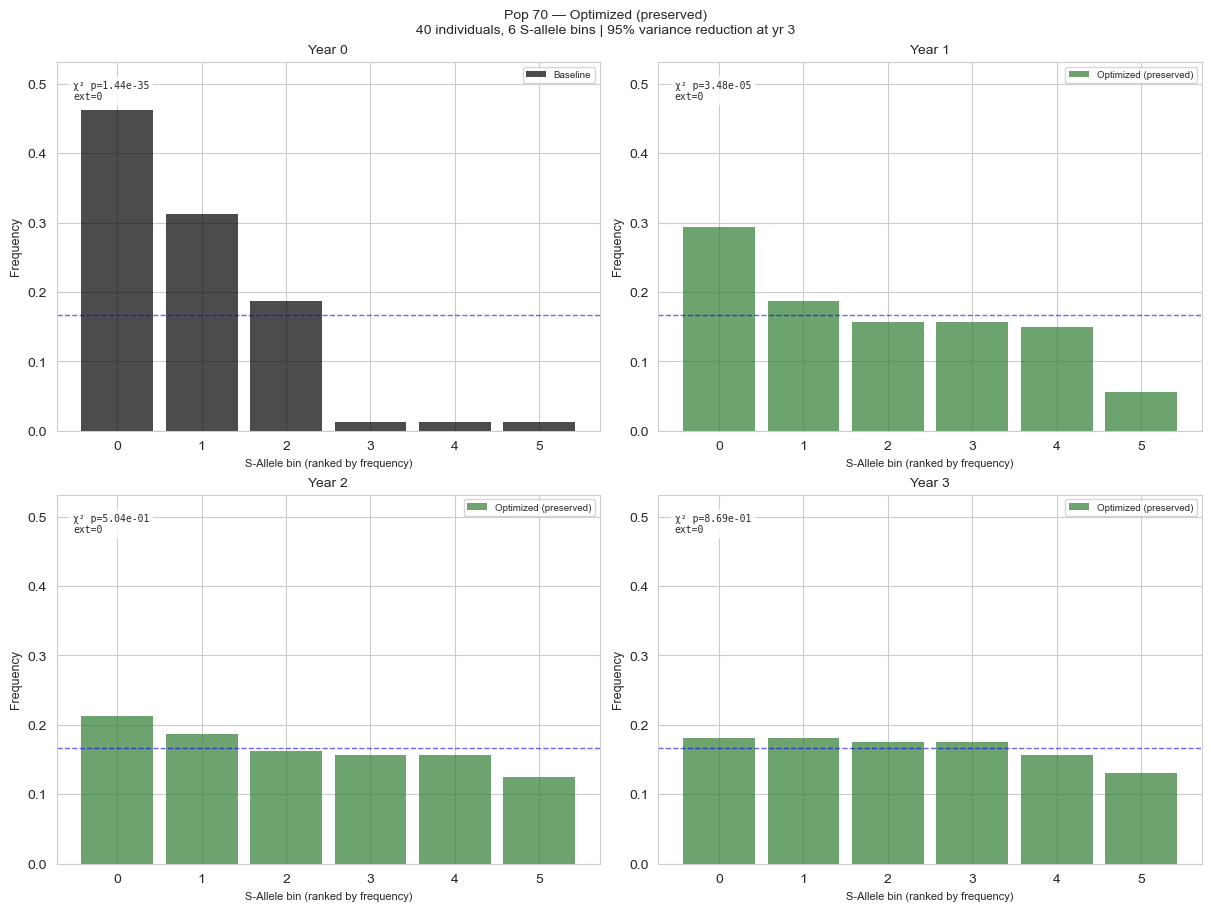

  Saved: ../outputs/figures/sallele_pop76_allele_freq_random.png


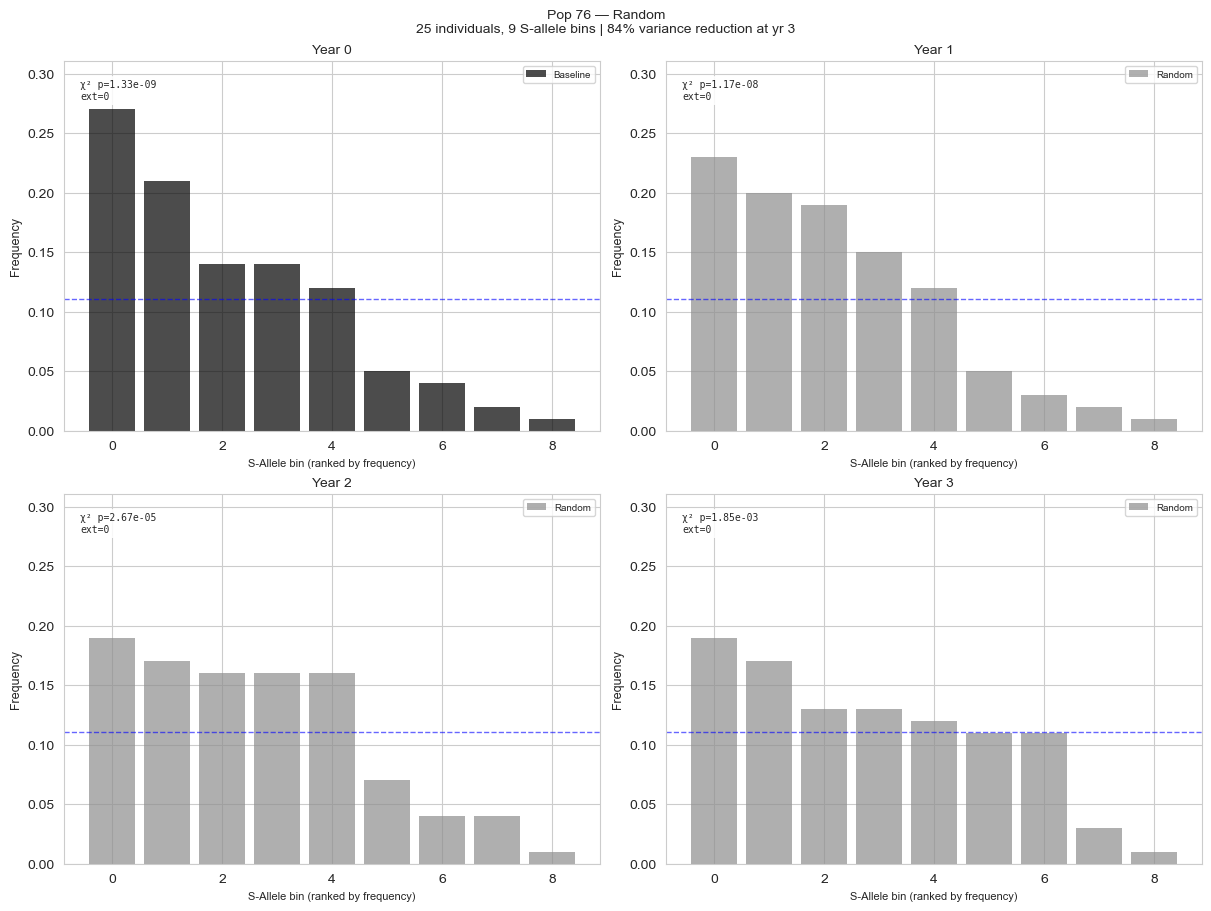

  Saved: ../outputs/figures/sallele_pop76_allele_freq_preserved.png


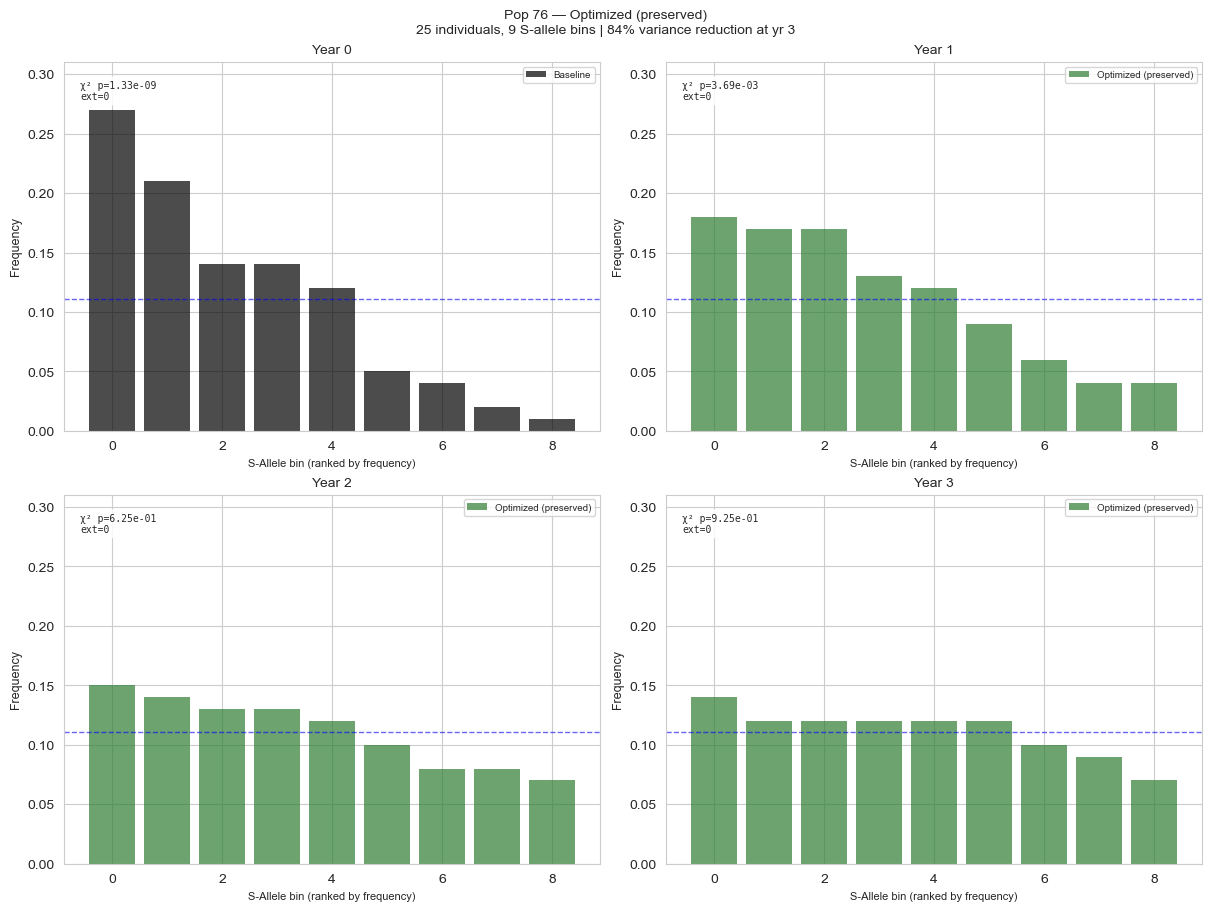

In [11]:
def save_figure(fig, pop_id, strategy_key):
    """Save figure with a descriptive name based on population and strategy."""
    fname = f"sallele_pop{pop_id}_allele_freq_{strategy_key}.png"
    path = os.path.join(FIGURES_DIR, fname)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"  Saved: {path}")

COLOR_PRESERVED_GREEN = "#2e7d32"

for pop_id in major_pops:
    gd = group_data[pop_id]
    alleles = gd["allele_pool"]
    target = gd["target_freq"]
    n_ind = len(gd["pop"])
    n_alleles = len(alleles)

    y_max = 0
    for yr in SNAPSHOT_YEARS:
        for key in ["random", "optimized", "preserved"]:
            snap = gd[key]["snapshots"].get(yr, gd["pop"])
            f = allele_frequencies(snap, alleles)
            y_max = max(y_max, max(f.values()))
    y_max *= 1.15

    yr3_improv_p = (1 - gd["preserved"]["variance_mean"][3] /
                    max(gd["random"]["variance_mean"][3], 1e-12)) * 100

    for strategy_key, strategy_label, strategy_color in [
        ("random",    "Random",                COLOR_RANDOM),
        ("preserved", "Optimized (preserved)", COLOR_PRESERVED_GREEN),
    ]:
        fig, axes = plt.subplots(2, 2, figsize=(12, 9), layout="constrained")
        fig.suptitle(f"Pop {pop_id} — {strategy_label}\n"
                     f"{n_ind} individuals, {n_alleles} S-allele bins | "
                     f"{yr3_improv_p:.0f}% variance reduction at yr 3",
                     fontsize=10)

        for idx, yr in enumerate(SNAPSHOT_YEARS):
            ax = axes[idx // 2, idx % 2]
            snap = gd[strategy_key]["snapshots"].get(yr, gd["pop"])
            freqs = allele_frequencies(snap, alleles)
            sorted_alleles = sorted(alleles, key=lambda a: freqs.get(a, 0), reverse=True)
            vals = [freqs.get(a, 0) for a in sorted_alleles]
            x = np.arange(len(sorted_alleles))

            color = "black" if yr == 0 else strategy_color
            lbl   = "Baseline" if yr == 0 else strategy_label
            ax.bar(x, vals, width=0.85, color=color, alpha=0.7, edgecolor="none", label=lbl)

            from collections import Counter
            allele_counts = Counter(a for g in snap for a in g)
            obs = np.array([allele_counts.get(a, 0) for a in alleles])
            exp = np.full(len(alleles), obs.sum() / len(alleles))
            _, pval = chisquare(obs, f_exp=exp)
            d = distance_from_equilibrium(snap, alleles)
            ax.text(0.03, 0.95,
                    f"χ² p={pval:.2e}\next={d['extinct_alleles']}",
                    transform=ax.transAxes, ha="left", va="top", fontsize=7,
                    family="monospace",
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85))

            ax.axhline(y=target, color="blue", linestyle="--", alpha=0.6, linewidth=1)
            ax.set_ylim(0, y_max)
            ax.set_xlabel("S-Allele bin (ranked by frequency)", fontsize=8)
            ax.set_ylabel("Frequency", fontsize=9)
            ax.set_title(f"Year {yr}", fontsize=10)
            ax.legend(fontsize=7, loc="upper right")

        save_figure(fig, pop_id, strategy_key)
        plt.show()


### Within-Population Convergence: All Strategies

Three metrics over 5 years for each major population.

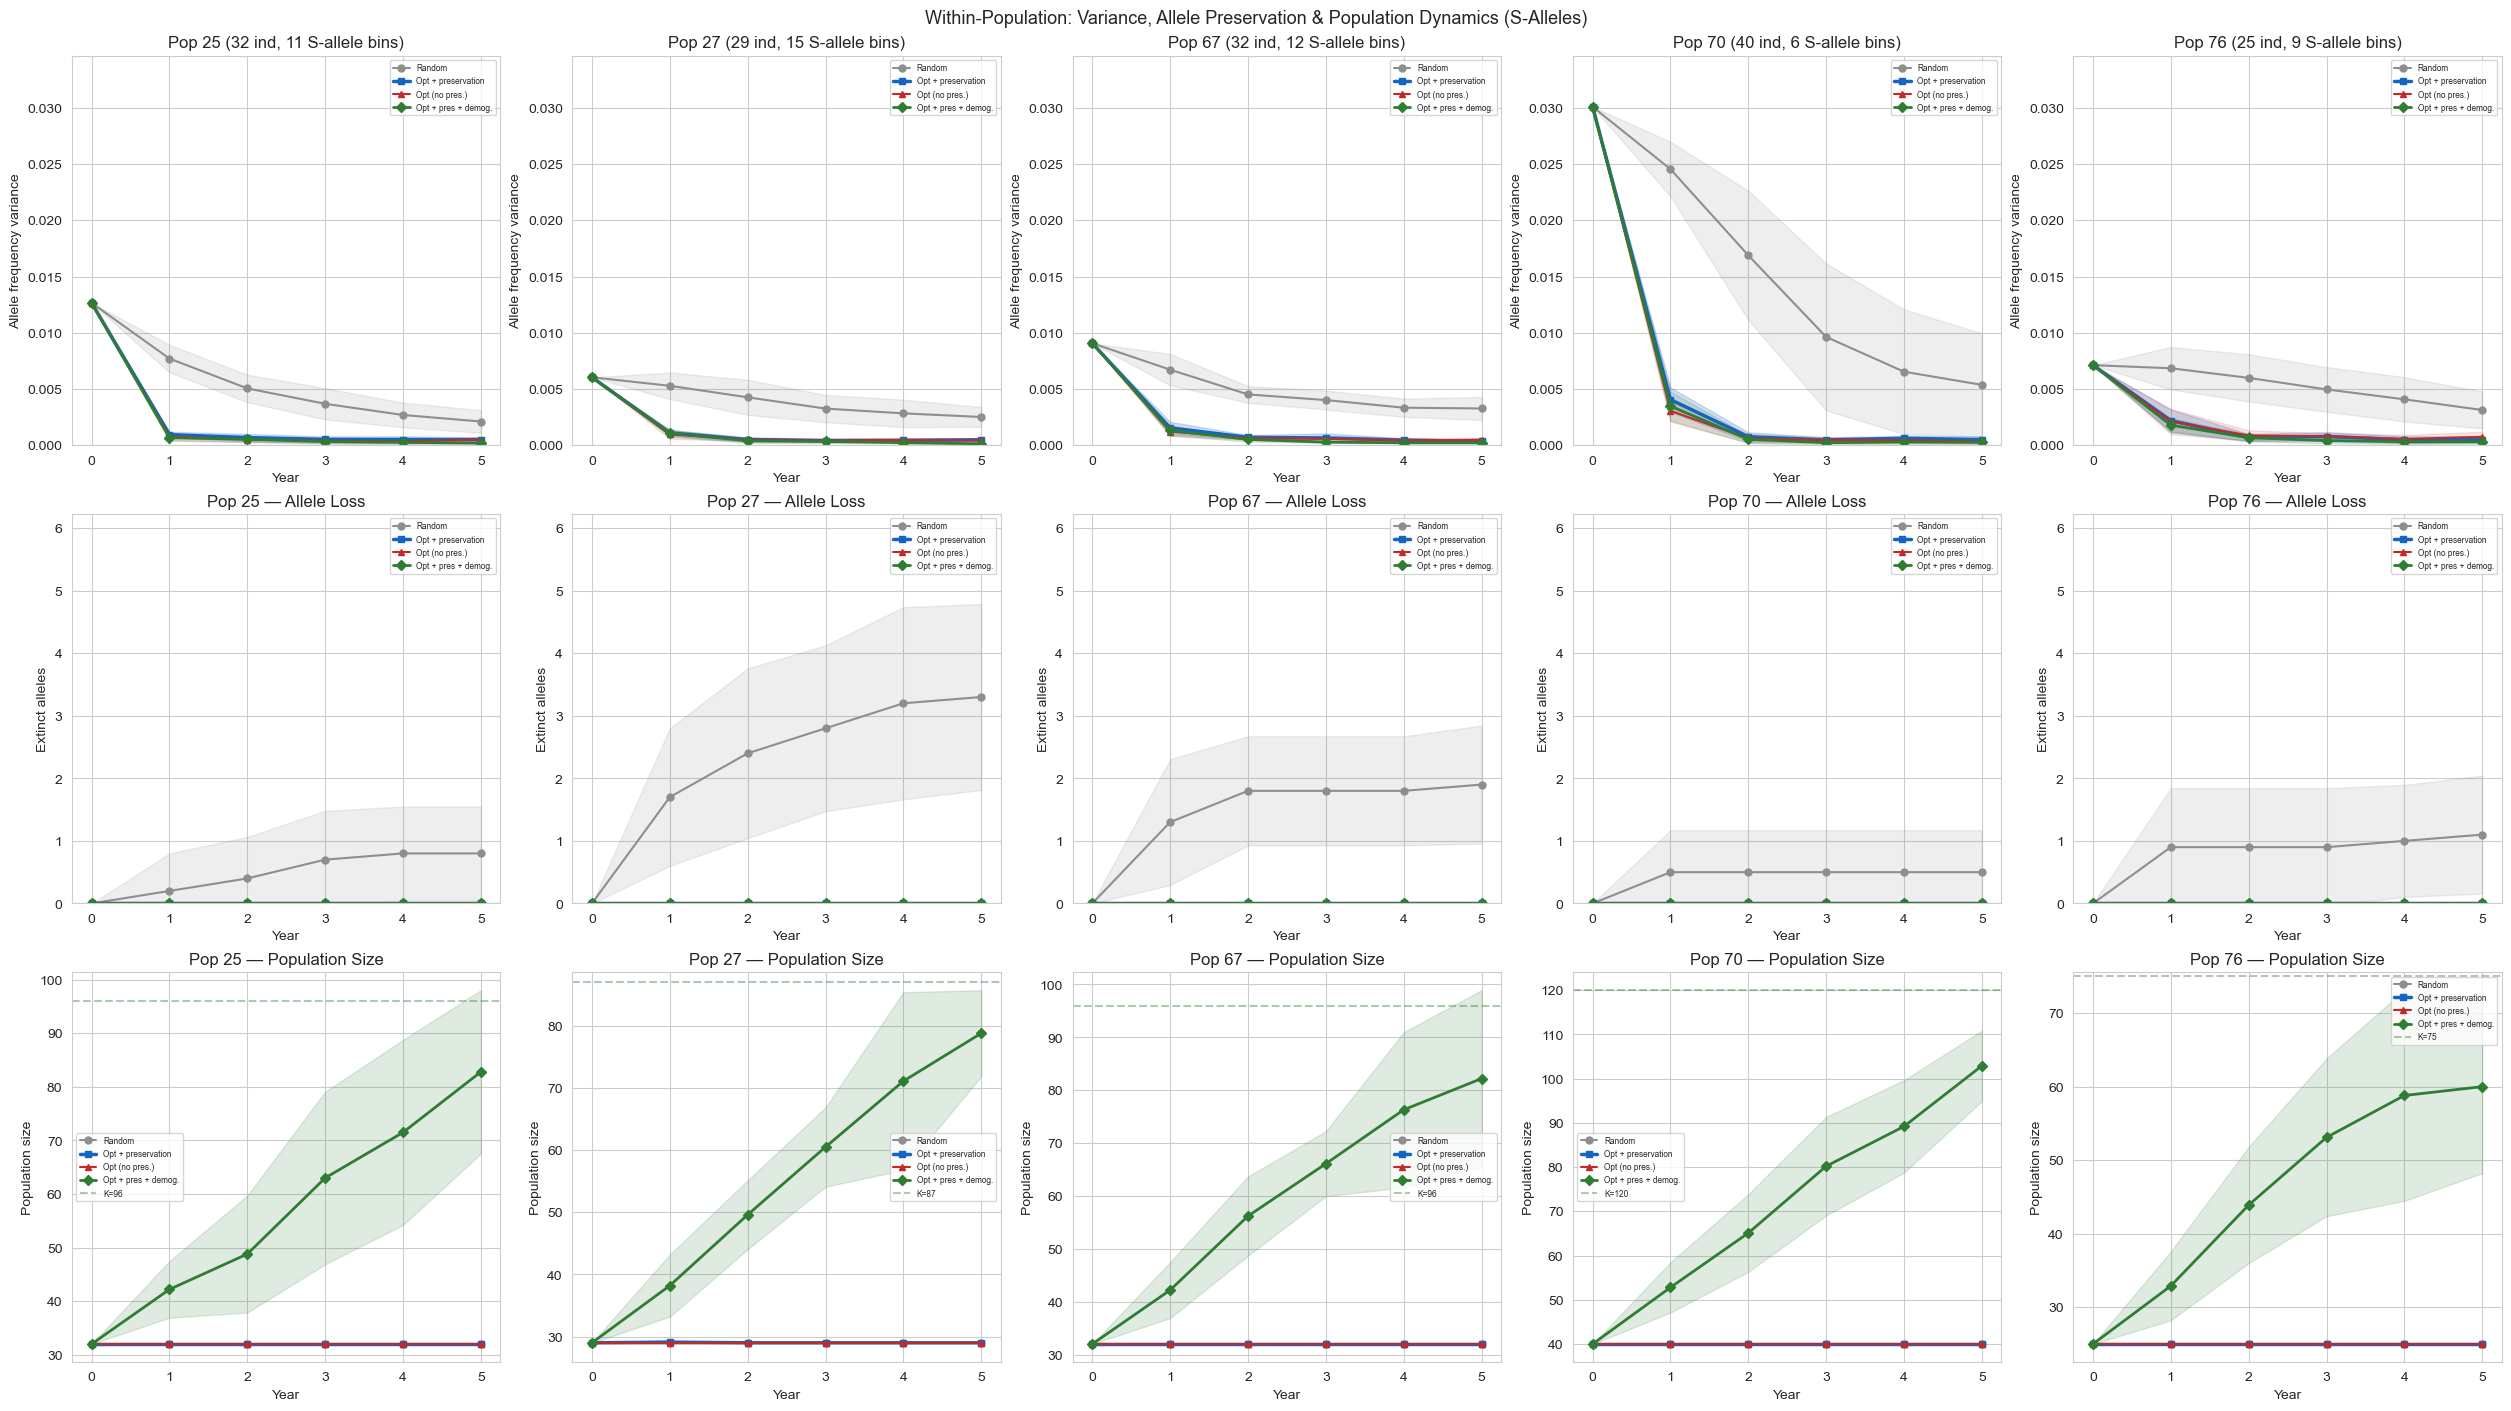

Saved: ../outputs/figures/sallele_pop27_convergence_variance.png


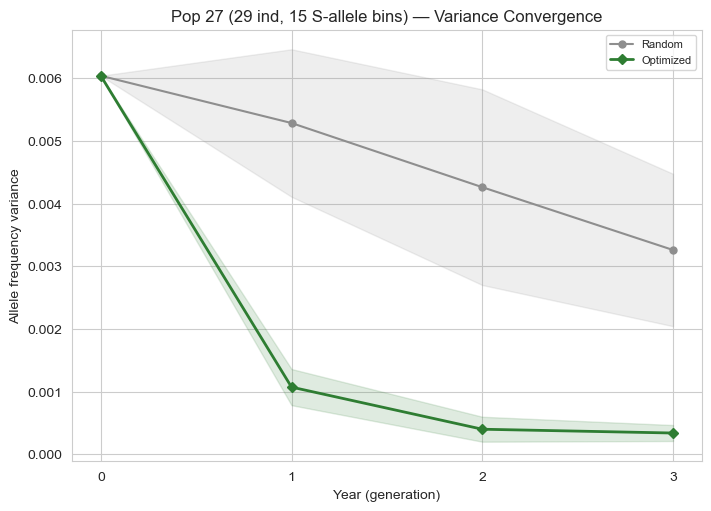

Saved: ../outputs/figures/sallele_pop27_convergence_allele_loss.png


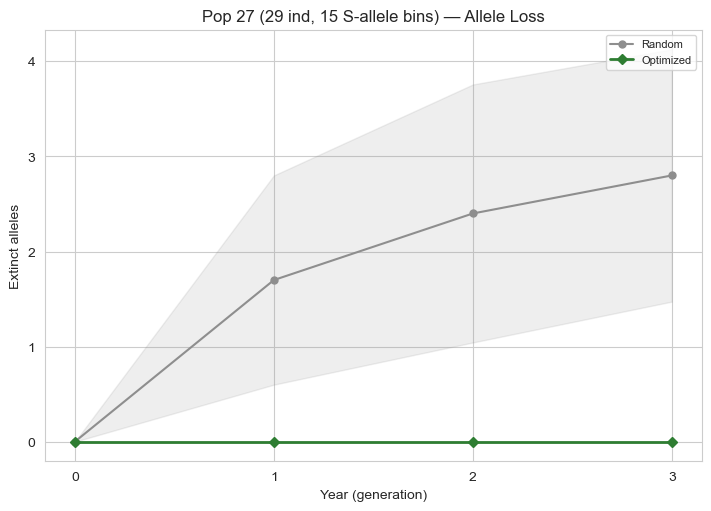

Saved: ../outputs/figures/sallele_pop27_convergence_population_size.png


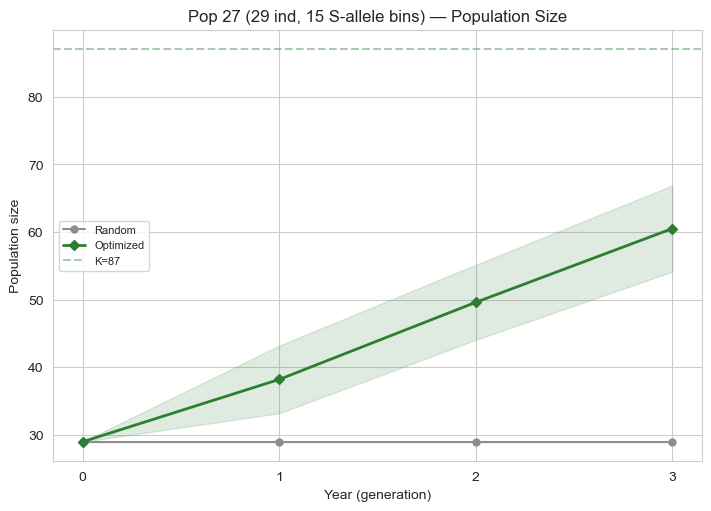

In [12]:
generations = np.arange(N_YEARS + 1)

strategy_specs = [
    ("random",      "Random",               COLOR_RANDOM,      "o", 1.5, 0.15),
    ("preserved",   "Opt + preservation",   COLOR_PRESERVED,   "s", 2.5, 0.2),
    ("optimized",   "Opt (no pres.)",        COLOR_ORIGINAL,    "^", 1.5, 0.12),
    ("demographic", "Opt + pres + demog.",   COLOR_DEMOGRAPHIC, "D", 2.0, 0.15),
]

# Shared y-axis maxima across all populations
y_max_var = 0
y_max_ext = 0
for pop_id in major_pops:
    gd = group_data[pop_id]
    for key in ["random", "optimized", "preserved", "demographic"]:
        res = gd[key]
        y_max_var = max(y_max_var, np.max(res["variance_mean"] + res["variance_std"]))
        y_max_ext = max(y_max_ext, np.max(res["extinct_mean"] + res["extinct_std"]))
y_max_var *= 1.15
y_max_ext = max(y_max_ext * 1.3, 1)

# ---- Combined multi-population grid ----
n_pops = len(major_pops)
fig, axes = plt.subplots(3, n_pops, figsize=(5 * n_pops, 14), layout="constrained")

for idx, pop_id in enumerate(major_pops):
    ax_var = axes[0, idx]
    ax_ext = axes[1, idx]
    ax_pop = axes[2, idx]
    gd = group_data[pop_id]
    N0 = len(gd["pop"])
    K = max(N0 * 3, 30)

    for key, label, color, marker, lw, alpha in strategy_specs:
        res = gd[key]
        for ax, metric in [(ax_var, "variance"), (ax_ext, "extinct"), (ax_pop, "pop_size")]:
            mean_key = f"{metric}_mean"
            std_key  = f"{metric}_std"
            ax.plot(generations, res[mean_key], f"-{marker}", color=color,
                    markersize=5, label=label, linewidth=lw)
            ax.fill_between(generations,
                            res[mean_key] - res[std_key],
                            res[mean_key] + res[std_key],
                            alpha=alpha, color=color)

    ax_var.set_xlabel("Year"); ax_var.set_ylabel("Allele frequency variance")
    ax_var.set_title(f"Pop {pop_id} ({N0} ind, {len(gd['allele_pool'])} S-allele bins)")
    ax_var.legend(fontsize=6); ax_var.set_xticks(generations)
    ax_var.set_ylim(0, y_max_var)

    ax_ext.set_xlabel("Year"); ax_ext.set_ylabel("Extinct alleles")
    ax_ext.set_title(f"Pop {pop_id} — Allele Loss")
    ax_ext.legend(fontsize=6); ax_ext.set_xticks(generations)
    ax_ext.set_ylim(0, y_max_ext)

    ax_pop.axhline(K, color=COLOR_DEMOGRAPHIC, linestyle="--", alpha=0.4, label=f"K={K}")
    ax_pop.set_xlabel("Year"); ax_pop.set_ylabel("Population size")
    ax_pop.set_title(f"Pop {pop_id} — Population Size")
    ax_pop.legend(fontsize=6); ax_pop.set_xticks(generations)

fig.suptitle("Within-Population: Variance, Allele Preservation & Population Dynamics (S-Alleles)", fontsize=13)
plt.show()

# ---- Save Pop 27 panels as individual figures (years 0–3, Random vs Optimized only) ----
if "27" in major_pops:
    gd27 = group_data["27"]
    N0_27 = len(gd27["pop"])
    K_27  = max(N0_27 * 3, 30)
    pop27_gens = np.arange(4)  # generations 0, 1, 2, 3
    pop27_specs = [
        ("random",      "Random",    COLOR_RANDOM,      "o", 1.5, 0.15),
        ("demographic", "Optimized", COLOR_DEMOGRAPHIC, "D", 2.0, 0.15),
    ]

    for metric, ylabel, title_suffix, fname in [
        ("variance",  "Allele frequency variance", "Variance Convergence",
         "sallele_pop27_convergence_variance.png"),
        ("extinct",   "Extinct alleles",            "Allele Loss",
         "sallele_pop27_convergence_allele_loss.png"),
        ("pop_size",  "Population size",            "Population Size",
         "sallele_pop27_convergence_population_size.png"),
    ]:
        fig, ax = plt.subplots(figsize=(7, 5), layout="constrained")
        for key, label, color, marker, lw, alpha in pop27_specs:
            res = gd27[key]
            mean_vals = res[f"{metric}_mean"][:4]
            std_vals  = res[f"{metric}_std"][:4]
            ax.plot(pop27_gens, mean_vals, f"-{marker}", color=color,
                    markersize=5, label=label, linewidth=lw)
            ax.fill_between(pop27_gens, mean_vals - std_vals, mean_vals + std_vals,
                            alpha=alpha, color=color)
        if metric == "pop_size":
            ax.axhline(K_27, color=COLOR_DEMOGRAPHIC, linestyle="--", alpha=0.4, label=f"K={K_27}")
        ax.set_xlabel("Year (generation)")
        ax.set_ylabel(ylabel)
        ax.set_title(f"Pop 27 ({N0_27} ind, {len(gd27['allele_pool'])} S-allele bins) — {title_suffix}")
        ax.legend(fontsize=8)
        ax.set_xticks(pop27_gens)
        path = os.path.join(FIGURES_DIR, fname)
        fig.savefig(path, dpi=150, bbox_inches="tight")
        print(f"Saved: {path}")
        plt.show()


### Strategy Comparison: Variance Reduction & Allele Loss

Within-Population Strategy Comparison (S-Alleles)
Pres% = preservation vs random | Demo% = demographic vs random
Pop  N   K  S-allele bins  Initial var Pres% (yr1) Demo% (yr1)  Ext Rand (yr1)  Ext Pres (yr1)  Ext Demo (yr1) Pres% (yr2) Demo% (yr2)  Ext Rand (yr2)  Ext Pres (yr2)  Ext Demo (yr2) Pres% (yr5) Demo% (yr5)  Ext Rand (yr5)  Ext Pres (yr5)  Ext Demo (yr5)
 25 32  96             11       0.0127         88%         91%          0.2000          0.0000          0.0000         87%         89%          0.4000          0.0000          0.0000         77%         91%          0.8000          0.0000          0.0000
 27 29  87             15       0.0060         79%         80%          1.7000          0.0000          0.0000         88%         91%          2.4000          0.0000          0.0000         81%         95%          3.3000          0.0000          0.0000
 67 32  96             12       0.0091         77%         80%          1.3000          0.0000          0.0000         84%

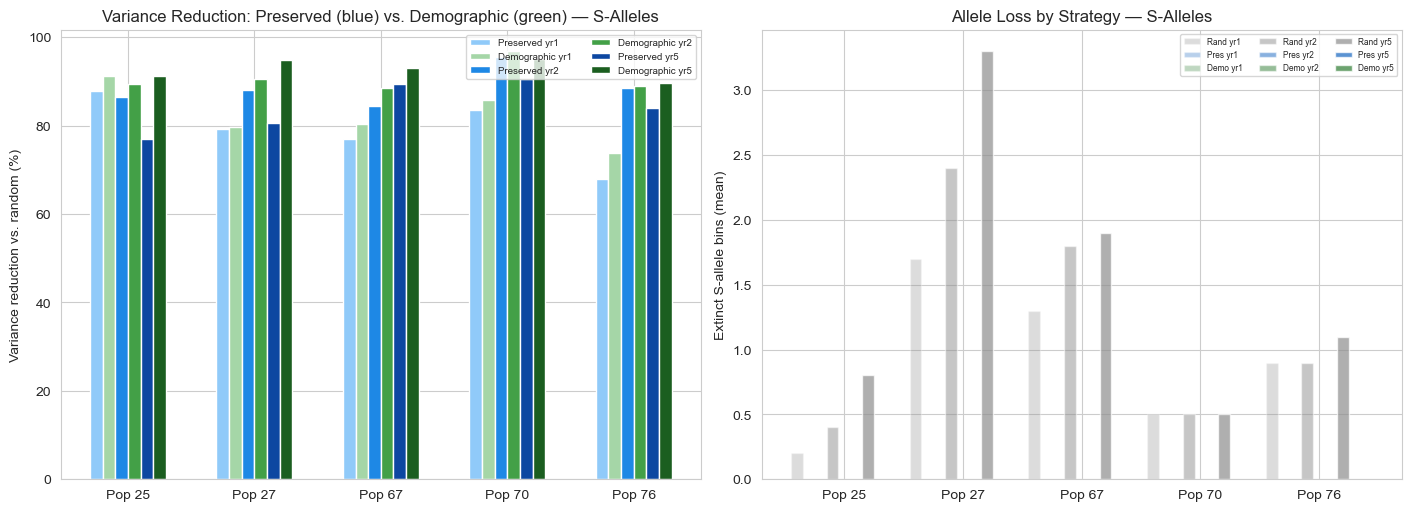

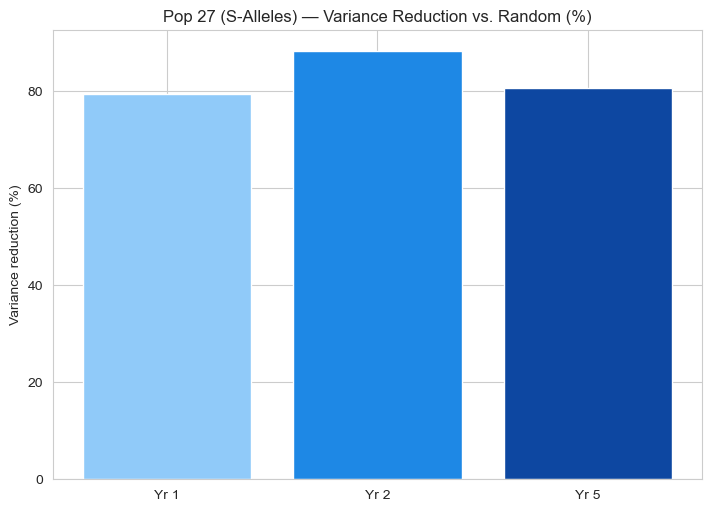

Saved: ../outputs/figures/sallele_pop27_strategy_comparison_allele_loss.png


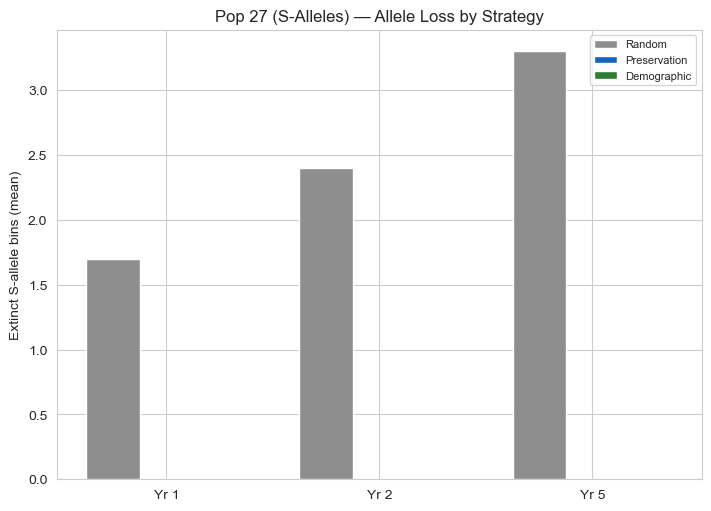

In [13]:
improvement_rows = []
for pop_id in major_pops:
    gd = group_data[pop_id]
    r = gd["random"]; o = gd["optimized"]; p = gd["preserved"]; dm = gd["demographic"]
    N0 = len(gd["pop"]); K = max(N0 * 3, 30)
    row = {"Pop": pop_id, "N": N0, "K": K, "S-allele bins": len(gd["allele_pool"]),
           "Initial var": r["variance_mean"][0]}
    for yr in [1, 2, 5]:
        rv = r["variance_mean"][yr]; pv = p["variance_mean"][yr]; dv = dm["variance_mean"][yr]
        row[f"Pres% (yr{yr})"]    = f"{(1 - pv / max(rv, 1e-12)) * 100:.0f}%"
        row[f"Demo% (yr{yr})"]    = f"{(1 - dv / max(rv, 1e-12)) * 100:.0f}%"
        row[f"Ext Rand (yr{yr})"] = r["extinct_mean"][yr]
        row[f"Ext Pres (yr{yr})"] = p["extinct_mean"][yr]
        row[f"Ext Demo (yr{yr})"] = dm["extinct_mean"][yr]
    improvement_rows.append(row)

imp_df = pd.DataFrame(improvement_rows)
print("Within-Population Strategy Comparison (S-Alleles)")
print("Pres% = preservation vs random | Demo% = demographic vs random")
print("=" * 120)
print(imp_df.to_string(index=False, float_format="{:.4f}".format))

# Bar chart: variance reduction % and allele extinction
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), layout="constrained")
x = np.arange(len(major_pops))
width = 0.1

for i, yr in enumerate([1, 2, 5]):
    imps_p, imps_d, exts_r, exts_p, exts_d = [], [], [], [], []
    for pop_id in major_pops:
        gd = group_data[pop_id]
        rv = gd["random"]["variance_mean"][yr]
        pv = gd["preserved"]["variance_mean"][yr]
        dv = gd["demographic"]["variance_mean"][yr]
        imps_p.append((1 - pv / max(rv, 1e-12)) * 100)
        imps_d.append((1 - dv / max(rv, 1e-12)) * 100)
        exts_r.append(gd["random"]["extinct_mean"][yr])
        exts_p.append(gd["preserved"]["extinct_mean"][yr])
        exts_d.append(gd["demographic"]["extinct_mean"][yr])

    blue_shades  = ["#90caf9", "#1e88e5", "#0d47a1"]
    green_shades = ["#a5d6a7", "#43a047", "#1b5e20"]
    ax1.bar(x + i * width * 2,         imps_p, width, label=f"Preserved yr{yr}",   color=blue_shades[i])
    ax1.bar(x + i * width * 2 + width, imps_d, width, label=f"Demographic yr{yr}", color=green_shades[i])
    ax2.bar(x + i * width * 3,             exts_r, width, label=f"Rand yr{yr}", color=COLOR_RANDOM,      alpha=0.3 + 0.2*i)
    ax2.bar(x + i * width * 3 + width,     exts_p, width, label=f"Pres yr{yr}", color=COLOR_PRESERVED,   alpha=0.3 + 0.2*i)
    ax2.bar(x + i * width * 3 + 2*width,   exts_d, width, label=f"Demo yr{yr}", color=COLOR_DEMOGRAPHIC, alpha=0.3 + 0.2*i)

ax1.set_xticks(x + width * 2.5)
ax1.set_xticklabels([f"Pop {p}" for p in major_pops])
ax1.set_ylabel("Variance reduction vs. random (%)")
ax1.set_title("Variance Reduction: Preserved (blue) vs. Demographic (green) — S-Alleles")
ax1.legend(fontsize=7, ncol=2)
ax1.axhline(y=0, color="gray", linewidth=0.5)

ax2.set_xticks(x + width * 4)
ax2.set_xticklabels([f"Pop {p}" for p in major_pops])
ax2.set_ylabel("Extinct S-allele bins (mean)")
ax2.set_title("Allele Loss by Strategy — S-Alleles")
ax2.legend(fontsize=6, ncol=3)

# Save Pop 27 strategy comparison as individual figures
if "27" in major_pops:
    for fig_title, metric_label, metric_fn, fname in [
        ("Variance Reduction vs. Random (%)", "Variance reduction (%)",
         lambda gd, yr: (1 - gd["preserved"]["variance_mean"][yr] /
                         max(gd["random"]["variance_mean"][yr], 1e-12)) * 100,
         "sallele_pop27_strategy_comparison_variance_reduction.png"),
        ("Allele Loss by Strategy", "Extinct S-allele bins (mean)",
         None, "sallele_pop27_strategy_comparison_allele_loss.png"),
    ]:
        fig27, ax27 = plt.subplots(figsize=(7, 5), layout="constrained")
        gd27 = group_data["27"]
        years_plot = [1, 2, 5]
        if metric_fn is not None:
            vals = [metric_fn(gd27, yr) for yr in years_plot]
            ax27.bar(range(len(years_plot)), vals, color=["#90caf9", "#1e88e5", "#0d47a1"],
                     tick_label=[f"Yr {yr}" for yr in years_plot])
            ax27.set_ylabel(metric_label)
        else:
            w2 = 0.25
            xs = np.arange(len(years_plot))
            ax27.bar(xs - w2,   [gd27["random"]["extinct_mean"][yr] for yr in years_plot],
                     w2, label="Random", color=COLOR_RANDOM)
            ax27.bar(xs,        [gd27["preserved"]["extinct_mean"][yr] for yr in years_plot],
                     w2, label="Preservation", color=COLOR_PRESERVED)
            ax27.bar(xs + w2,   [gd27["demographic"]["extinct_mean"][yr] for yr in years_plot],
                     w2, label="Demographic", color=COLOR_DEMOGRAPHIC)
            ax27.set_xticks(xs)
            ax27.set_xticklabels([f"Yr {yr}" for yr in years_plot])
            ax27.set_ylabel(metric_label)
            ax27.legend(fontsize=8)
        ax27.set_title(f"Pop 27 (S-Alleles) — {fig_title}")
        path = os.path.join(FIGURES_DIR, fname)
        fig27.savefig(path, dpi=150, bbox_inches="tight")
        print(f"Saved: {path}")
        plt.show()

plt.show()


### Top Recommended Crosses (Per Population)

In [14]:
for pop_id in major_pops:
    gd     = group_data[pop_id]
    cc     = gd["compatible_crosses"]
    ow     = gd["optimal_weights"]
    names  = gd["individuals"]
    target = gd["target_freq"]
    d      = distance_from_equilibrium(gd["pop"], gd["allele_pool"])
    aem    = gd["allele_effect_matrix"]

    rows = []
    for k in range(len(cc)):
        i, j, compat = cc[k]
        expected_freqs = aem[k]
        chi_sq = float(np.sum((expected_freqs - target) ** 2 / target))
        rows.append({
            "Maternal":      names[i],
            "Pollen donor":  names[j],
            "Compatibility": compat,
            "Impact score":  d["chi_squared"] - chi_sq,
            "Optimal weight": ow[k],
        })

    df = pd.DataFrame(rows)
    top = df.nlargest(10, "Optimal weight")
    print(f"\nPop {pop_id} — Top 10 recommended crosses (S-Allele):")
    print(top.to_string(index=False))


Pop 25 — Top 10 recommended crosses (S-Allele):
            Maternal         Pollen donor  Compatibility  Impact score  Optimal weight
Library003_barcode61 Library003_barcode62       0.500000     -1.937622        0.011476
Library003_barcode61 Library004_barcode81       1.000000     -0.562622        0.011476
Library003_barcode61 Library005_barcode25       1.000000     -0.562622        0.011476
Library003_barcode62 Library003_barcode61       0.500000     -1.937622        0.011476
Library003_barcode72 Library005_barcode25       0.166667     -2.968872        0.011476
Library004_barcode81 Library003_barcode61       1.000000     -0.562622        0.011476
Library005_barcode23 Library005_barcode25       0.166667     -1.937622        0.011476
Library005_barcode25 Library003_barcode61       1.000000     -0.562622        0.011476
Library005_barcode26 Library005_barcode25       0.166667     -2.968872        0.011476
Library005_barcode32 Library004_barcode81       0.166667     -1.937622        0.0

## Part B: Cross-Population Analysis

All ingroup individuals treated as a single metapopulation. Allows the optimiser to identify
inter-population crosses — especially valuable for singleton alleles in minor or isolated populations.

In [15]:
%%time

global_alleles = sorted(set(a for g in population_genotypes for a in g))
global_target  = 1.0 / len(global_alleles)
N_global       = len(population_genotypes)
K_global       = max(N_global * 2, 200)

print(f"Global population: {N_global} individuals, {len(global_alleles)} allele bins")
print(f"Target frequency: 1/{len(global_alleles)} = {global_target:.4f}")
print(f"Carrying capacity K = {K_global}")
print(f"Total directed pairs: {N_global * (N_global - 1)}")
print("Enumerating compatible crosses...")

global_cc, global_aem = enumerate_compatible_crosses(population_genotypes, global_alleles)
n_total = N_global * (N_global - 1)
print(f"Compatible crosses: {len(global_cc)}/{n_total} ({100*len(global_cc)/n_total:.1f}%)")

Global population: 189 individuals, 47 allele bins
Target frequency: 1/47 = 0.0213
Carrying capacity K = 378
Total directed pairs: 35532
Enumerating compatible crosses...
Compatible crosses: 30141/35532 (84.8%)
CPU times: user 929 ms, sys: 17 ms, total: 946 ms
Wall time: 580 ms


In [16]:
%%time

print(f"Simulating {N_YEARS} years ({N_global} individuals, K={K_global})...")

print("Random mating...")
global_random = run_adaptive_simulation(
    population_genotypes, global_alleles, N_YEARS, "random", N_TRIALS, base_seed=BASE_SEED)

print("Optimized (no preservation)...")
global_optimized = run_adaptive_simulation(
    population_genotypes, global_alleles, N_YEARS, "optimized", N_TRIALS, base_seed=BASE_SEED)

print("Optimized + preservation...")
global_preserved = run_adaptive_simulation(
    population_genotypes, global_alleles, N_YEARS, "optimized", N_TRIALS,
    preserve_rare=True, rare_threshold=0.05, elite_frac=0.1, base_seed=BASE_SEED)

print("Optimized + preservation + demography...")
global_demographic = run_adaptive_simulation(
    population_genotypes, global_alleles, N_YEARS, "optimized", N_TRIALS,
    preserve_rare=True, rare_threshold=0.05, elite_frac=0.1,
    carrying_capacity=K_global, growth_rate=0.5, demographic_stochastic=True,
    base_seed=BASE_SEED)

print("\nResults:")
for yr in SNAPSHOT_YEARS:
    rv = global_random["variance_mean"][yr]
    pv = global_preserved["variance_mean"][yr]
    dv = global_demographic["variance_mean"][yr]
    print(f"  Year {yr}: Random var={rv:.6f}, "
          f"Pres={pv:.6f} ({(1-pv/max(rv,1e-12))*100:.0f}%), "
          f"Demo={dv:.6f} ({(1-dv/max(rv,1e-12))*100:.0f}%) | "
          f"Extinct R={global_random['extinct_mean'][yr]:.1f}, "
          f"P={global_preserved['extinct_mean'][yr]:.1f}, "
          f"D={global_demographic['extinct_mean'][yr]:.1f}")

Simulating 5 years (189 individuals, K=378)...
Random mating...
Optimized (no preservation)...


/var/folders/7q/9sxlsr1j6xg80n7_3mmyx_nr0000gp/T/ipykernel_15873/2326443061.py:127: RuntimeWarning: Mean of empty slice
  "ne_mean":          np.where(np.all(np.isnan(all_ne), axis=0), np.nan, np.nanmean(all_ne, axis=0)),
/Users/sven/anaconda3/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Optimized + preservation...
Optimized + preservation + demography...

Results:
  Year 0: Random var=0.002418, Pres=0.002418 (0%), Demo=0.002418 (0%) | Extinct R=0.0, P=0.0, D=0.0
  Year 1: Random var=0.001817, Pres=0.000098 (95%), Demo=0.000082 (96%) | Extinct R=3.5, P=0.0, D=0.0
  Year 2: Random var=0.001299, Pres=0.000045 (97%), Demo=0.000029 (98%) | Extinct R=5.9, P=0.0, D=0.0
  Year 3: Random var=0.000880, Pres=0.000032 (96%), Demo=0.000023 (97%) | Extinct R=7.4, P=0.0, D=0.0
CPU times: user 19min 51s, sys: 10min 41s, total: 30min 33s
Wall time: 6min 41s


### Cross-Population Allele Frequencies by Strategy

Saved: ../outputs/figures/sallele_cross_pop_allele_freq_random.png


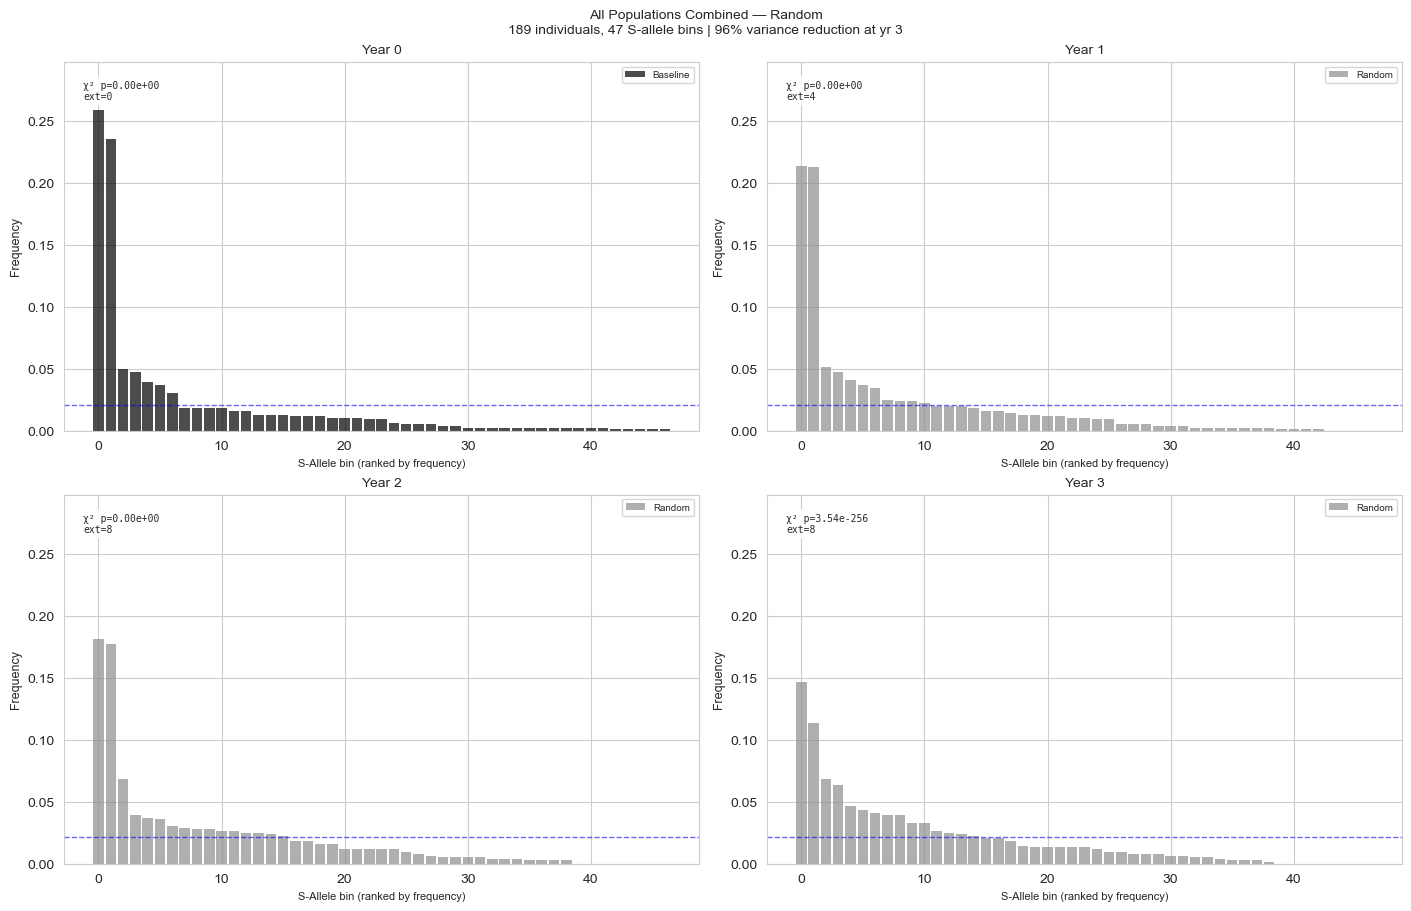

Saved: ../outputs/figures/sallele_cross_pop_allele_freq_random_vs_preservation.png


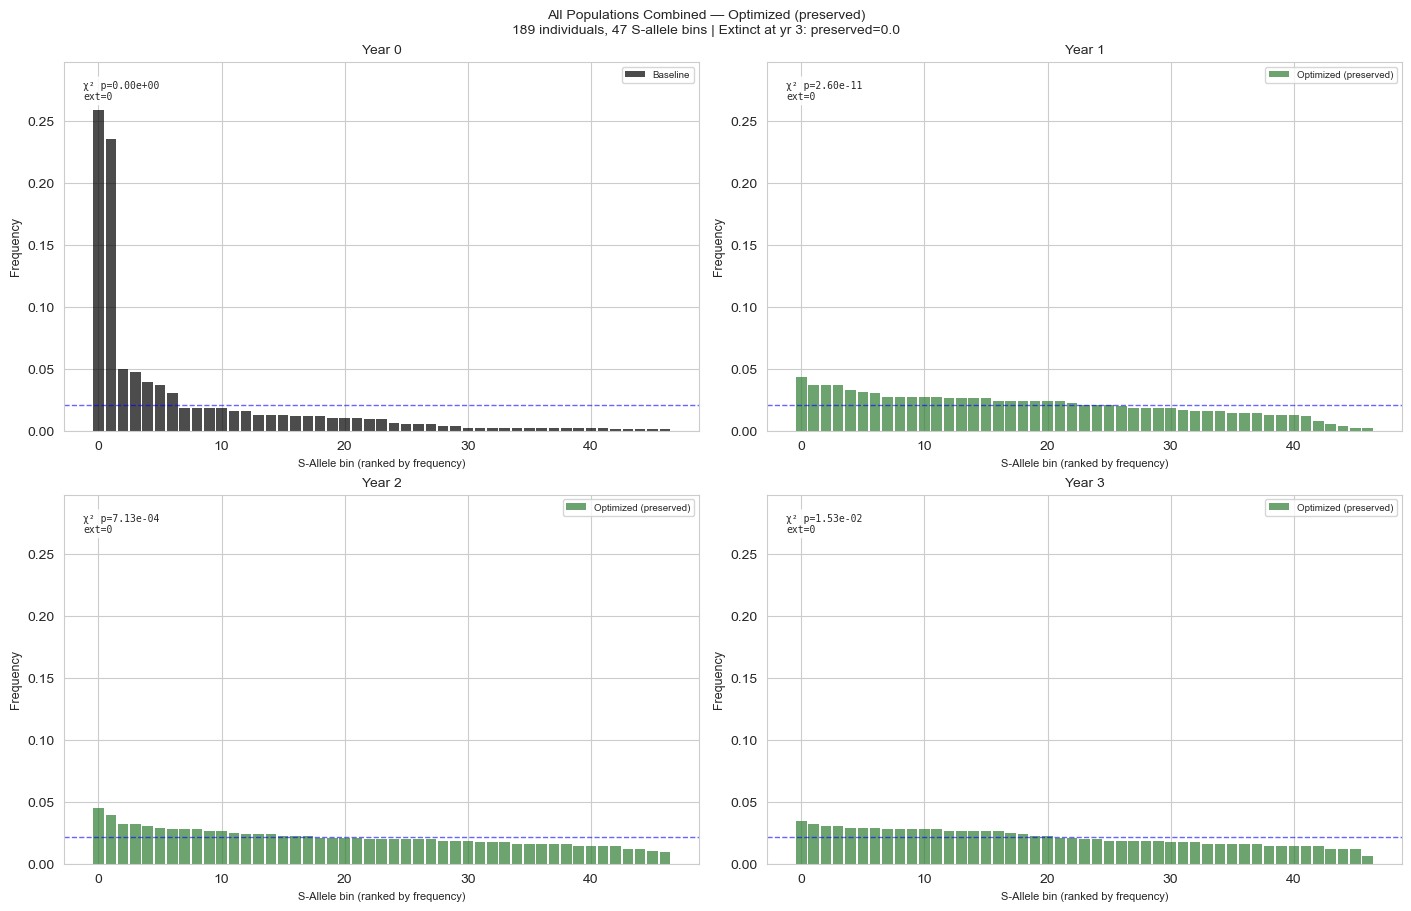

In [17]:
yr3_rv = global_random["variance_mean"][3]
yr3_pv = global_preserved["variance_mean"][3]
yr3_improv_p = (1 - yr3_pv / max(yr3_rv, 1e-12)) * 100
yr3_ext_p = global_preserved["extinct_mean"][3]

COLOR_PRESERVED_GREEN = "#2e7d32"

y_max = 0
for yr in SNAPSHOT_YEARS:
    for res in [global_random, global_preserved]:
        snap = res["snapshots"].get(yr, population_genotypes)
        f = allele_frequencies(snap, global_alleles)
        y_max = max(y_max, max(f.values()))
y_max *= 1.15

for strategy_res, strategy_label, strategy_color, ext_line, fname in [
    (global_random,    "Random",                COLOR_RANDOM,
     f"{yr3_improv_p:.0f}% variance reduction at yr 3",
     "sallele_cross_pop_allele_freq_random.png"),
    (global_preserved, "Optimized (preserved)", COLOR_PRESERVED_GREEN,
     f"Extinct at yr 3: preserved={yr3_ext_p:.1f}",
     "sallele_cross_pop_allele_freq_random_vs_preservation.png"),
]:
    fig, axes = plt.subplots(2, 2, figsize=(14, 9), layout="constrained")
    fig.suptitle(f"All Populations Combined — {strategy_label}\n"
                 f"{N_global} individuals, {len(global_alleles)} S-allele bins | {ext_line}",
                 fontsize=10)

    for idx, yr in enumerate(SNAPSHOT_YEARS):
        ax = axes[idx // 2, idx % 2]
        snap = strategy_res["snapshots"].get(yr, population_genotypes)
        freqs = allele_frequencies(snap, global_alleles)
        sorted_alleles = sorted(global_alleles, key=lambda a: freqs.get(a, 0), reverse=True)
        vals = [freqs.get(a, 0) for a in sorted_alleles]
        x = np.arange(len(sorted_alleles))

        color = "black" if yr == 0 else strategy_color
        lbl   = "Baseline" if yr == 0 else strategy_label
        ax.bar(x, vals, width=0.85, color=color, alpha=0.7, edgecolor="none", label=lbl)

        from collections import Counter
        allele_counts = Counter(a for g in snap for a in g)
        obs = np.array([allele_counts.get(a, 0) for a in global_alleles])
        exp = np.full(len(global_alleles), obs.sum() / len(global_alleles))
        _, pval = chisquare(obs, f_exp=exp)
        d = distance_from_equilibrium(snap, global_alleles)
        ax.text(0.03, 0.95,
                f"χ² p={pval:.2e}\next={d['extinct_alleles']}",
                transform=ax.transAxes, ha="left", va="top", fontsize=7,
                family="monospace",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85))

        ax.axhline(y=global_target, color="blue", linestyle="--", alpha=0.6, linewidth=1)
        ax.set_ylim(0, y_max)
        ax.set_xlabel("S-Allele bin (ranked by frequency)", fontsize=8)
        ax.set_ylabel("Frequency", fontsize=9)
        ax.set_title(f"Year {yr}", fontsize=10)
        ax.legend(fontsize=7, loc="upper right")

    path = os.path.join(FIGURES_DIR, fname)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Saved: {path}")
    plt.show()


### Cross-Population Convergence

Saved: ../outputs/figures/sallele_cross_pop_convergence_variance.png


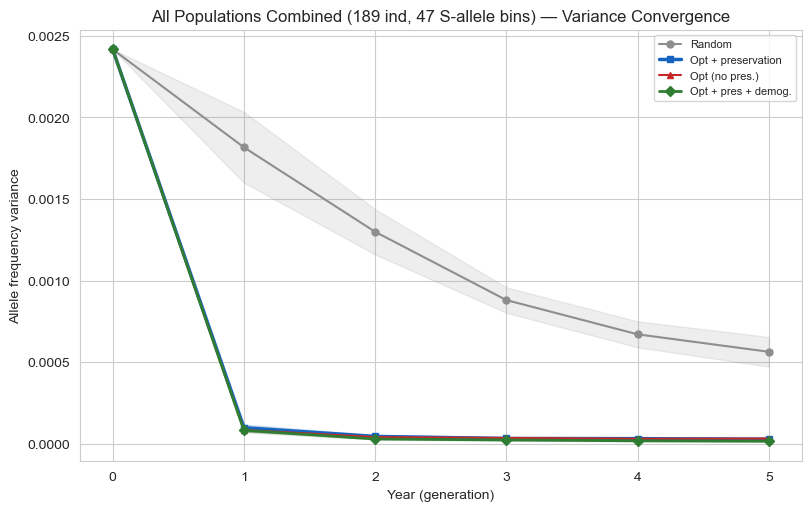

Saved: ../outputs/figures/sallele_cross_pop_convergence_allele_loss.png


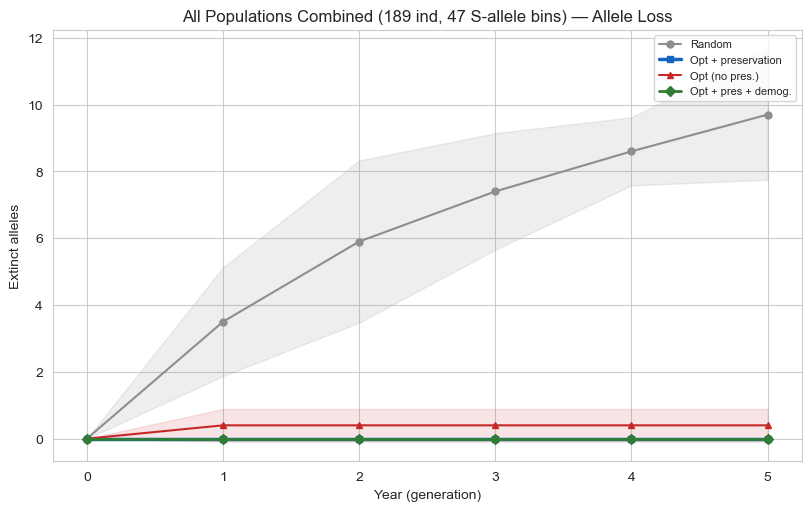

Saved: ../outputs/figures/sallele_cross_pop_convergence_population_size.png


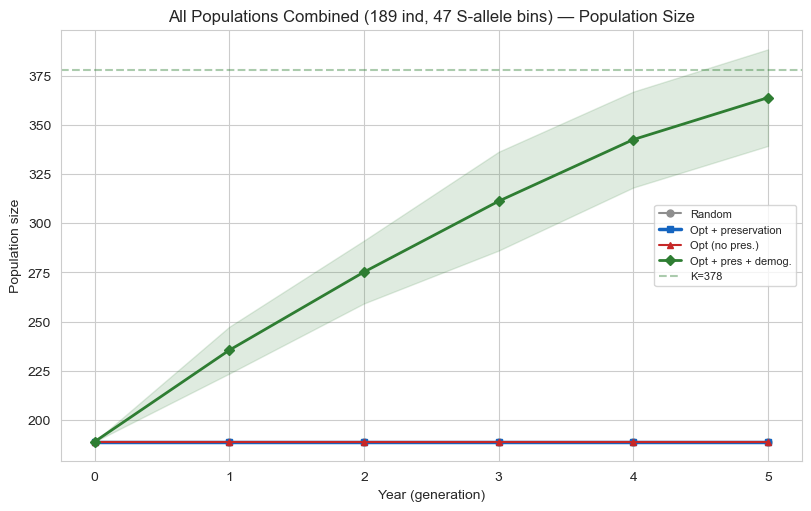

In [18]:
global_strategy_specs = [
    (global_random,      "Random",               COLOR_RANDOM,      "o", 1.5, 0.15),
    (global_preserved,   "Opt + preservation",   COLOR_PRESERVED,   "s", 2.5, 0.2),
    (global_optimized,   "Opt (no pres.)",        COLOR_ORIGINAL,    "^", 1.5, 0.12),
    (global_demographic, "Opt + pres + demog.",   COLOR_DEMOGRAPHIC, "D", 2.0, 0.15),
]

for metric, ylabel, title_suffix, fname in [
    ("variance",  "Allele frequency variance", "Variance Convergence",
     "sallele_cross_pop_convergence_variance.png"),
    ("extinct",   "Extinct alleles",            "Allele Loss",
     "sallele_cross_pop_convergence_allele_loss.png"),
    ("pop_size",  "Population size",            "Population Size",
     "sallele_cross_pop_convergence_population_size.png"),
]:
    fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")
    for res, label, color, marker, lw, alpha in global_strategy_specs:
        mean_vals = res[f"{metric}_mean"]
        std_vals  = res[f"{metric}_std"]
        ax.plot(generations, mean_vals, f"-{marker}", color=color,
                markersize=5, label=label, linewidth=lw)
        ax.fill_between(generations, mean_vals - std_vals, mean_vals + std_vals,
                        alpha=alpha, color=color)
    if metric == "pop_size":
        ax.axhline(K_global, color=COLOR_DEMOGRAPHIC, linestyle="--", alpha=0.4, label=f"K={K_global}")
    ax.set_xlabel("Year (generation)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"All Populations Combined ({N_global} ind, {len(global_alleles)} S-allele bins) — {title_suffix}")
    ax.legend(fontsize=8)
    ax.set_xticks(generations)
    path = os.path.join(FIGURES_DIR, fname)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Saved: {path}")
    plt.show()


### Top Cross-Population Recommended Crosses

In [19]:
d_global = distance_from_equilibrium(population_genotypes, global_alleles)

# Optimise weights for cross-population crosses
global_opt_weights, global_opt_result = compute_optimal_weights(
    global_cc, global_aem, global_alleles, maxiter=5000)
print(f"Global optimisation: χ²={global_opt_result.fun:.6f}, "
      f"converged={global_opt_result.success}")

rows = []
for k in range(len(global_cc)):
    i, j, compat = global_cc[k]
    expected_freqs = global_aem[k]
    chi_sq  = float(np.sum((expected_freqs - global_target) ** 2 / global_target))
    mat_name = individual_names[i]
    pat_name = individual_names[j]
    rows.append({
        "Maternal":      mat_name,
        "Mat. Pop":      pop_map[mat_name],
        "Pollen donor":  pat_name,
        "Don. Pop":      pop_map[pat_name],
        "Cross type":    "inter-pop" if pop_map[mat_name] != pop_map[pat_name] else "intra-pop",
        "Impact score":  d_global["chi_squared"] - chi_sq,
        "Optimal weight": global_opt_weights[k],
    })

global_df = pd.DataFrame(rows)
print(f"\nTop 15 recommended crosses (species-wide, S-Allele):")
print(global_df.nlargest(15, "Optimal weight").to_string(index=False))
print(f"\nTop 15 inter-population recommended crosses:")
inter_df = global_df[global_df["Cross type"] == "inter-pop"]
print(inter_df.nlargest(15, "Optimal weight").to_string(index=False))

Global optimisation: χ²=0.073967, converged=True

Top 15 recommended crosses (species-wide, S-Allele):
            Maternal Mat. Pop         Pollen donor Don. Pop Cross type  Impact score  Optimal weight
Library007_barcode85       67 Library007_barcode82       67  intra-pop     -5.409553        0.065029
Library005_barcode23       25 Library005_barcode25       25  intra-pop    -12.753303        0.040680
Library001_barcode17       76 Library003_barcode66       76  intra-pop    -11.284553        0.035402
Library002_barcode32       48 Library002_barcode43      118  inter-pop     -6.878303        0.028443
Library004_barcode87       76 Library001_barcode17       76  intra-pop    -12.753303        0.023625
Library007_barcode82       67 Library007_barcode83       67  intra-pop     -9.815803        0.020287
Library002_barcode43      118 Library004_barcode82       25  inter-pop     -9.815803        0.015393
Library002_barcode31       25 Library005_barcode22       25  intra-pop    -11.284553     

## Summary

In [20]:
summary_rows = []

for pop_id in major_pops:
    gd = group_data[pop_id]
    r = gd["random"]; p = gd["preserved"]; dm = gd["demographic"]
    d = distance_from_equilibrium(gd["pop"], gd["allele_pool"])
    N0 = len(gd["pop"]); K = max(N0 * 3, 30)
    row = {
        "Analysis": f"Pop {pop_id}", "N": N0, "K": K,
        "Allele bins": len(gd["allele_pool"]),
        "Crosses": len(gd["compatible_crosses"]),
        "Initial χ²": d["chi_squared"],
        "Optimised χ²": gd["opt_result"].fun,
    }
    for yr in [1, 2, 5]:
        rv = r["variance_mean"][yr]; pv = p["variance_mean"][yr]; dv = dm["variance_mean"][yr]
        row[f"Pres% (yr{yr})"]    = f"{(1 - pv / max(rv, 1e-12)) * 100:.0f}%"
        row[f"Demo% (yr{yr})"]    = f"{(1 - dv / max(rv, 1e-12)) * 100:.0f}%"
        row[f"Ext Rand (yr{yr})"] = f"{r['extinct_mean'][yr]:.1f}"
        row[f"Ext Pres (yr{yr})"] = f"{p['extinct_mean'][yr]:.1f}"
    summary_rows.append(row)

# Cross-population row
d_g = distance_from_equilibrium(population_genotypes, global_alleles)
global_row = {
    "Analysis": "Cross-pop (all)",
    "N": N_global, "K": K_global,
    "Allele bins": len(global_alleles),
    "Crosses": len(global_cc),
    "Initial χ²": d_g["chi_squared"],
    "Optimised χ²": global_opt_result.fun,
}
for yr in [1, 2, 5]:
    rv = global_random["variance_mean"][yr]
    pv = global_preserved["variance_mean"][yr]
    dv = global_demographic["variance_mean"][yr]
    global_row[f"Pres% (yr{yr})"]    = f"{(1 - pv / max(rv, 1e-12)) * 100:.0f}%"
    global_row[f"Demo% (yr{yr})"]    = f"{(1 - dv / max(rv, 1e-12)) * 100:.0f}%"
    global_row[f"Ext Rand (yr{yr})"] = f"{global_random['extinct_mean'][yr]:.1f}"
    global_row[f"Ext Pres (yr{yr})"] = f"{global_preserved['extinct_mean'][yr]:.1f}"
summary_rows.append(global_row)

summary_df = pd.DataFrame(summary_rows)
print("=" * 90)
print("Summary — S-Allele Analysis")
print("=" * 90)
print(summary_df.to_string(index=False))

Summary — S-Allele Analysis
       Analysis   N   K  Allele bins  Crosses  Initial χ²  Optimised χ² Pres% (yr1) Demo% (yr1) Ext Rand (yr1) Ext Pres (yr1) Pres% (yr2) Demo% (yr2) Ext Rand (yr2) Ext Pres (yr2) Pres% (yr5) Demo% (yr5) Ext Rand (yr5) Ext Pres (yr5)
         Pop 25  32  96           11      749    1.531128  1.403529e-07         88%         91%            0.2            0.0         87%         89%            0.4            0.0         77%         91%            0.8            0.0
         Pop 27  29  87           15      692    1.358799  2.905569e-02         79%         80%            1.7            0.0         88%         91%            2.4            0.0         81%         95%            3.3            0.0
         Pop 67  32  96           12      802    1.305664  3.646833e-02         77%         80%            1.3            0.0         84%         89%            1.8            0.0         89%         93%            1.9            0.0
         Pop 70  40 120            6